<a href="https://colab.research.google.com/github/natthaphonmint/wave_prediction_project/blob/main/Data_Preparation/EDA_Hua_Sai_Nakhon_Si_Thammarat_4_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. ใส่ลิงก์หัวไทร
url_huasai = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/refs/heads/main/wave_data/Hua%20Sai_Nakhon%20Si%20Thammarat.csv'

# 2. อ่านข้อมูล
HuasaiNakhonThammarat = pd.read_csv(url_huasai)

# 3. ลองแสดงผล
HuasaiNakhonThammarat.head()

,Time,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
0,1/1/2018 0.00,1.199359,1.163536,0.267764,-5.229365,-1.745424,10.239930,85.015228,6.285251,299.826065,300.587845
1,1/1/2018 1.00,1.202724,1.127065,0.404244,-6.057752,-2.017640,10.223330,85.037537,6.253075,299.346794,300.587845
2,1/1/2018 2.00,1.219304,1.102313,0.516395,-6.188400,-2.061301,10.456569,84.609726,6.132920,299.302010,300.587845
3,1/1/2018 3.00,1.232462,1.108556,0.535049,-5.875643,-2.021169,10.303367,84.249283,6.029561,299.322075,300.587845
4,1/1/2018 4.00,1.233244,1.123493,0.500552,-5.469970,-1.736256,9.888147,84.241928,5.985807,299.465080,300.587845


In [5]:
display(f"Start date: {HuasaiNakhonThammarat.index.min()}")
display(f"End date: {HuasaiNakhonThammarat.index.max()}")

'Start date: 0'

'End date: 71543'

# การทำความสะอาดข้อมูลและเตรียมข้อมูล

In [6]:
!pip install missingno

/tmp/ipykernel_848/3533789877.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust layout to prevent labels from being cut off


<Figure size 1500x800 with 0 Axes>

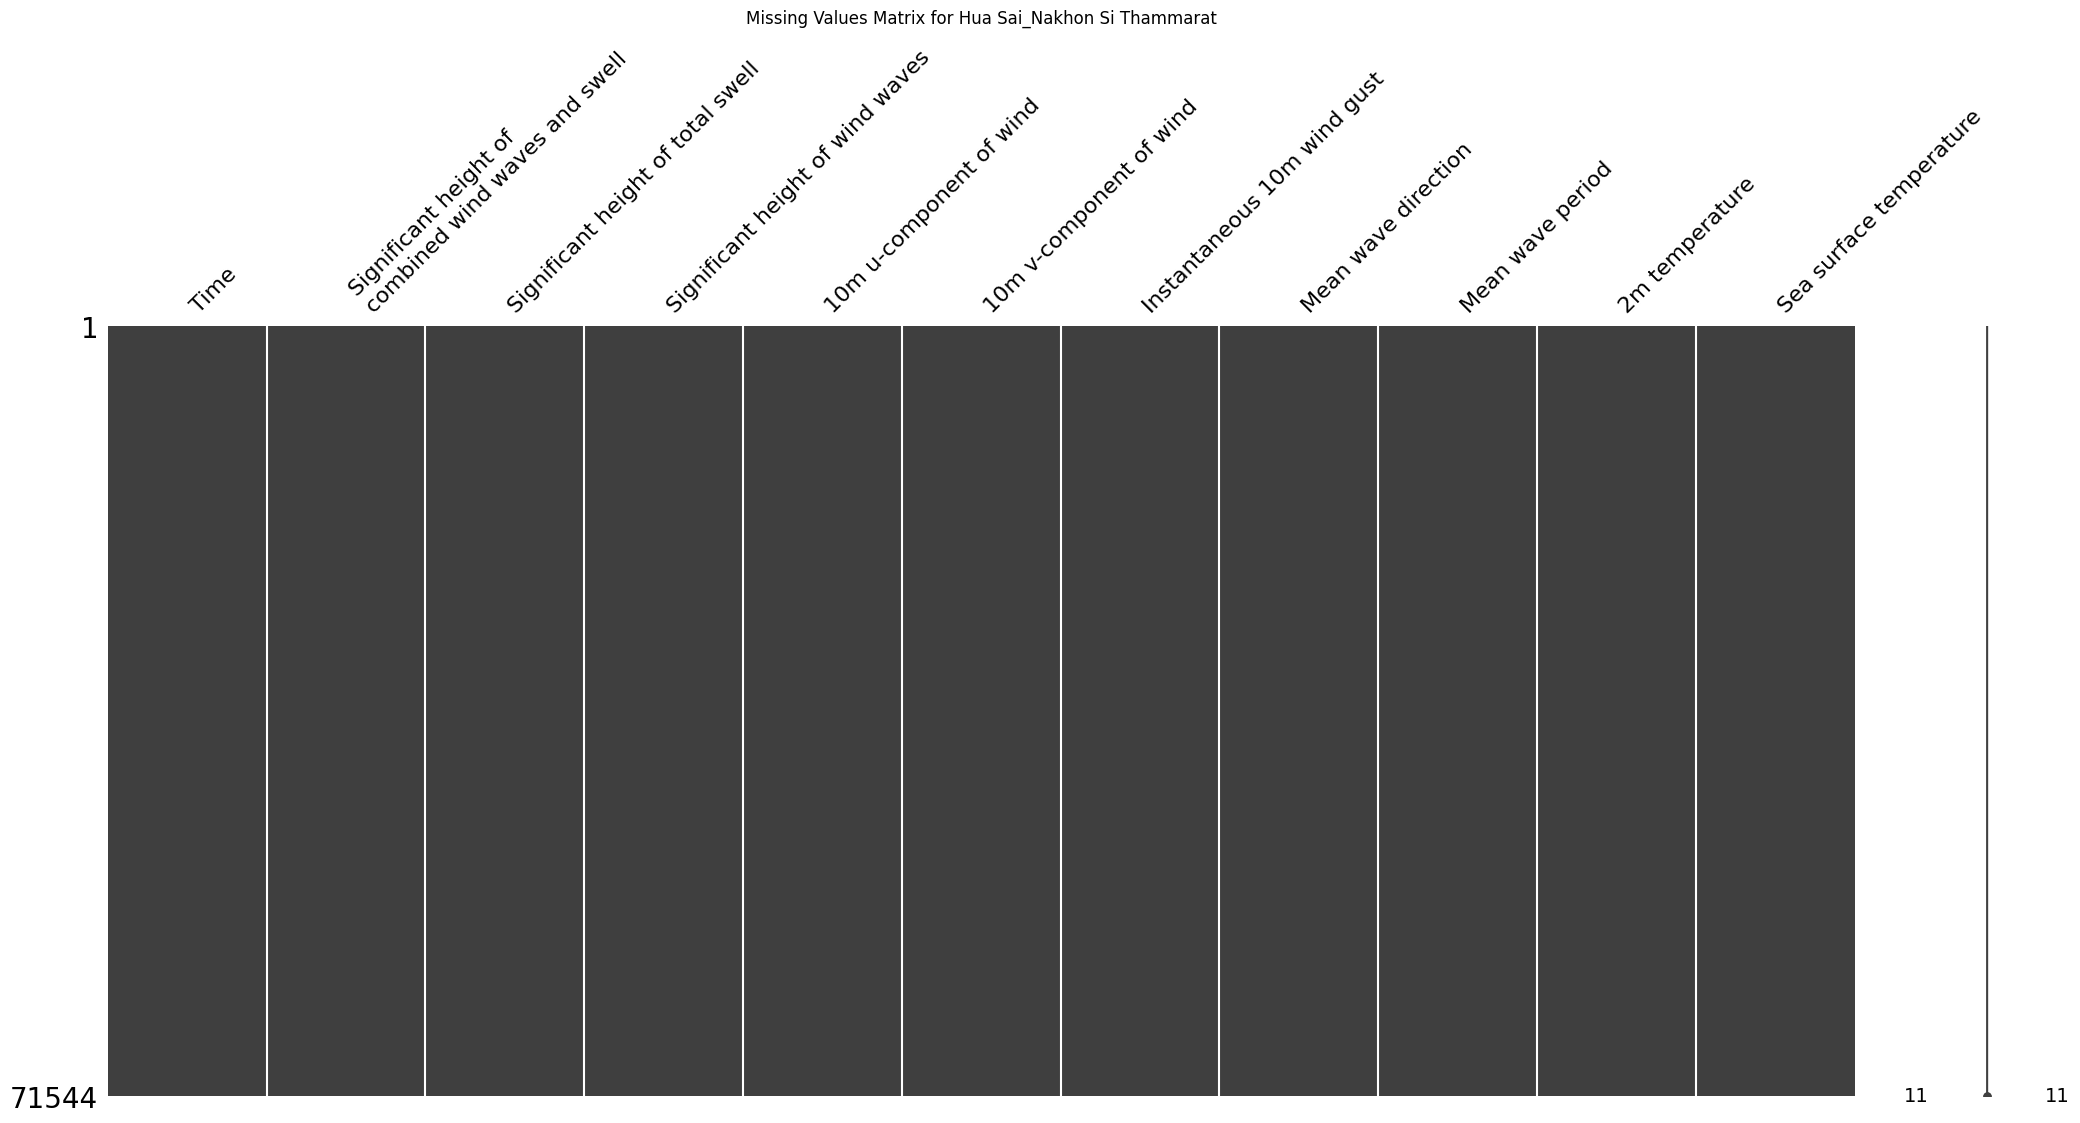

In [8]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8)) # Increased figure size for better readability
msno.matrix(HuasaiNakhonThammarat)
plt.title('Missing Values Matrix for Hua Sai_Nakhon Si Thammarat') # Added a title
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [9]:
# Check for missing values
missing_values = HuasaiNakhonThammarat.isnull().sum()
display("Missing values in each column:")
display(missing_values)

# Display concise summary of the DataFrame, including the number of non-null entries
display(HuasaiNakhonThammarat.info())

'Missing values in each column:'

,0
Time,0
Significant height of\ncombined wind waves and swell,0
Significant height of total swell,0
Significant height of wind waves,0
10m u-component of wind,0
10m v-component of wind,0
Instantaneous 10m wind gust,0
Mean wave direction,0
Mean wave period,0
2m temperature,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71544 entries, 0 to 71543
Data columns (total 11 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Time                                                 71544 non-null  object 
 1   Significant height of
combined wind waves and swell  71544 non-null  float64
 2   Significant height of total swell                    71544 non-null  float64
 3   Significant height of wind waves                     71544 non-null  float64
 4   10m u-component of wind                              71544 non-null  float64
 5   10m v-component of wind                              71544 non-null  float64
 6   Instantaneous 10m wind gust                          71544 non-null  float64
 7   Mean wave direction                                  71544 non-null  float64
 8   Mean wave period                                     71544 non-nul

None

คอลัมน์ทั้ง 8 คอลัมน์ ไม่มีค่าที่หายไป

In [12]:
# กำหนดให้คอลัมน์ 'Time' เป็น Index ของ DataFrame และแปลงเป็น DatetimeIndex
# First, convert the 'Time' column to a suitable string format
import re
HuasaiNakhonThammarat['Time'] = HuasaiNakhonThammarat['Time'].astype(str).apply(lambda x: re.sub(r'(\d{1,2})\.(\d{2})$', r'\1:\2', x))

HuasaiNakhonThammarat_indexed = HuasaiNakhonThammarat.set_index('Time')
HuasaiNakhonThammarat_indexed.index = pd.to_datetime(HuasaiNakhonThammarat_indexed.index, format='%d/%m/%Y %H:%M', dayfirst=True)

# แสดงข้อความและ 5 แถวแรกของ DataFrame เพื่อให้เห็นว่าคอลัมน์ 'Time' ได้กลายเป็น Index
display("DataFrame with 'Time' as datetime index:")
display(HuasaiNakhonThammarat_indexed.head())

# แสดงชนิดข้อมูลของแต่ละคอลัมน์
display("Data types including index type:")
display(HuasaiNakhonThammarat_indexed.dtypes)

"DataFrame with 'Time' as datetime index:"

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2018-01-01 00:00:00,1.199359,1.163536,0.267764,-5.229365,-1.745424,10.239930,85.015228,6.285251,299.826065,300.587845
2018-01-01 01:00:00,1.202724,1.127065,0.404244,-6.057752,-2.017640,10.223330,85.037537,6.253075,299.346794,300.587845
2018-01-01 02:00:00,1.219304,1.102313,0.516395,-6.188400,-2.061301,10.456569,84.609726,6.132920,299.302010,300.587845
2018-01-01 03:00:00,1.232462,1.108556,0.535049,-5.875643,-2.021169,10.303367,84.249283,6.029561,299.322075,300.587845
2018-01-01 04:00:00,1.233244,1.123493,0.500552,-5.469970,-1.736256,9.888147,84.241928,5.985807,299.465080,300.587845


'Data types including index type:'

,0
Significant height of\ncombined wind waves and swell,float64
Significant height of total swell,float64
Significant height of wind waves,float64
10m u-component of wind,float64
10m v-component of wind,float64
Instantaneous 10m wind gust,float64
Mean wave direction,float64
Mean wave period,float64
2m temperature,float64
Sea surface temperature,float64


In [14]:
# ตรวจสอบ time difference ระหว่างแถวที่ติดกัน
time_diff = HuasaiNakhonThammarat_indexed.index.to_series().diff().dropna()

# สร้างเวกเตอร์ของ time difference
time_diff_vector = time_diff.values

# ตรวจสอบว่า time difference ทั้งหมดเท่ากับ 1 ชั่วโมงหรือไม่
# เนื่องจาก time_diff เป็น TimedeltaIndex, เราสามารถเปรียบเทียบกับ pd.Timedelta(hours=1)
is_one_hour = (time_diff == pd.Timedelta(hours=1))

# ตรวจสอบว่ามีค่าใดที่ไม่เท่ากับ 1 ชั่วโมงหรือไม่
if not is_one_hour.all():
    display("พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:")
    display(time_diff[~is_one_hour])
else:
    display("ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด")

    display("ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:")
display(time_diff.head())
display("...")
display(time_diff.tail())

'ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด'

'ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:'

,Time
Time,
2018-01-01 01:00:00,0 days 01:00:00
2018-01-01 02:00:00,0 days 01:00:00
2018-01-01 03:00:00,0 days 01:00:00
2018-01-01 04:00:00,0 days 01:00:00
2018-01-01 05:00:00,0 days 01:00:00


'...'

,Time
Time,
2026-02-28 19:00:00,0 days 01:00:00
2026-02-28 20:00:00,0 days 01:00:00
2026-02-28 21:00:00,0 days 01:00:00
2026-02-28 22:00:00,0 days 01:00:00
2026-02-28 23:00:00,0 days 01:00:00


In [16]:
# Check for duplicate rows
duplicate_rows = HuasaiNakhonThammarat_indexed[HuasaiNakhonThammarat_indexed.duplicated()]

if duplicate_rows.empty:
    display("ไม่มีแถวที่ซ้ำกันในข้อมูล")
else:
    display("พบแถวที่ซ้ำกันในข้อมูล:")
    display(duplicate_rows)

'ไม่มีแถวที่ซ้ำกันในข้อมูล'

In [17]:
# ตรวจสอบว่ามี "เวลา" (ซึ่งเป็น Index) ซ้ำซ้อนกันหรือไม่
index_duplicates = HuasaiNakhonThammarat_indexed.index.duplicated()

if not index_duplicates.any():
    display("ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)")
    display("ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว")
else:
    display("พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!")

    # แสดงให้เห็นว่าเวลาไหนที่ซ้ำ
    duplicate_times = HuasaiNakhonThammarat_indexed.index[index_duplicates].unique()
    display(f"พบเวลาที่ซ้ำซ้อนกัน {len(duplicate_times)} จุดเวลา:")
    display(duplicate_times)

    # แสดงแถวที่ซ้ำทั้งหมด (ทั้งแถวเก่าและแถวใหม่ที่ซ้ำกัน)
    display("แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:")
    display(HuasaiNakhonThammarat_indexed[HuasaiNakhonThammarat_indexed.index.duplicated(keep=False)])

"ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)"

'ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว'

# สำรวจและวิเคราะห์ข้อมูลเบื้องต้น (Exploratory Data Analysis - EDA)

In [20]:
# Display basic descriptive statistics
display("Basic descriptive statistics for the DataFrame:")
display(HuasaiNakhonThammarat_indexed.describe())

'Basic descriptive statistics for the DataFrame:'

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
count,71544.000000,71544.000000,7.154400e+04,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000
mean,0.535649,0.426701,2.652448e-01,-0.756347,0.473659,6.796830,145.416721,3.782844,300.939131,302.654727
std,0.338490,0.264996,2.687363e-01,4.467675,2.062158,2.644453,83.461505,0.933291,1.064530,0.974001
min,0.086257,0.031553,2.470000e-16,-13.579407,-17.848770,1.229706,0.013305,1.962597,297.720528,300.507408
25%,0.279230,0.227614,5.862596e-02,-4.487998,-0.658393,4.775580,88.985889,3.019147,300.165340,301.788086
50%,0.438045,0.325289,1.914597e-01,-1.395169,0.784042,6.556817,99.783104,3.589866,300.869545,302.820564
75%,0.707217,0.574365,3.889277e-01,3.043072,1.880587,8.533411,237.604023,4.488510,301.666056,303.418984
max,3.983704,2.697005,2.977104e+00,11.715465,12.025506,23.265549,359.971924,7.703200,305.524719,305.141731


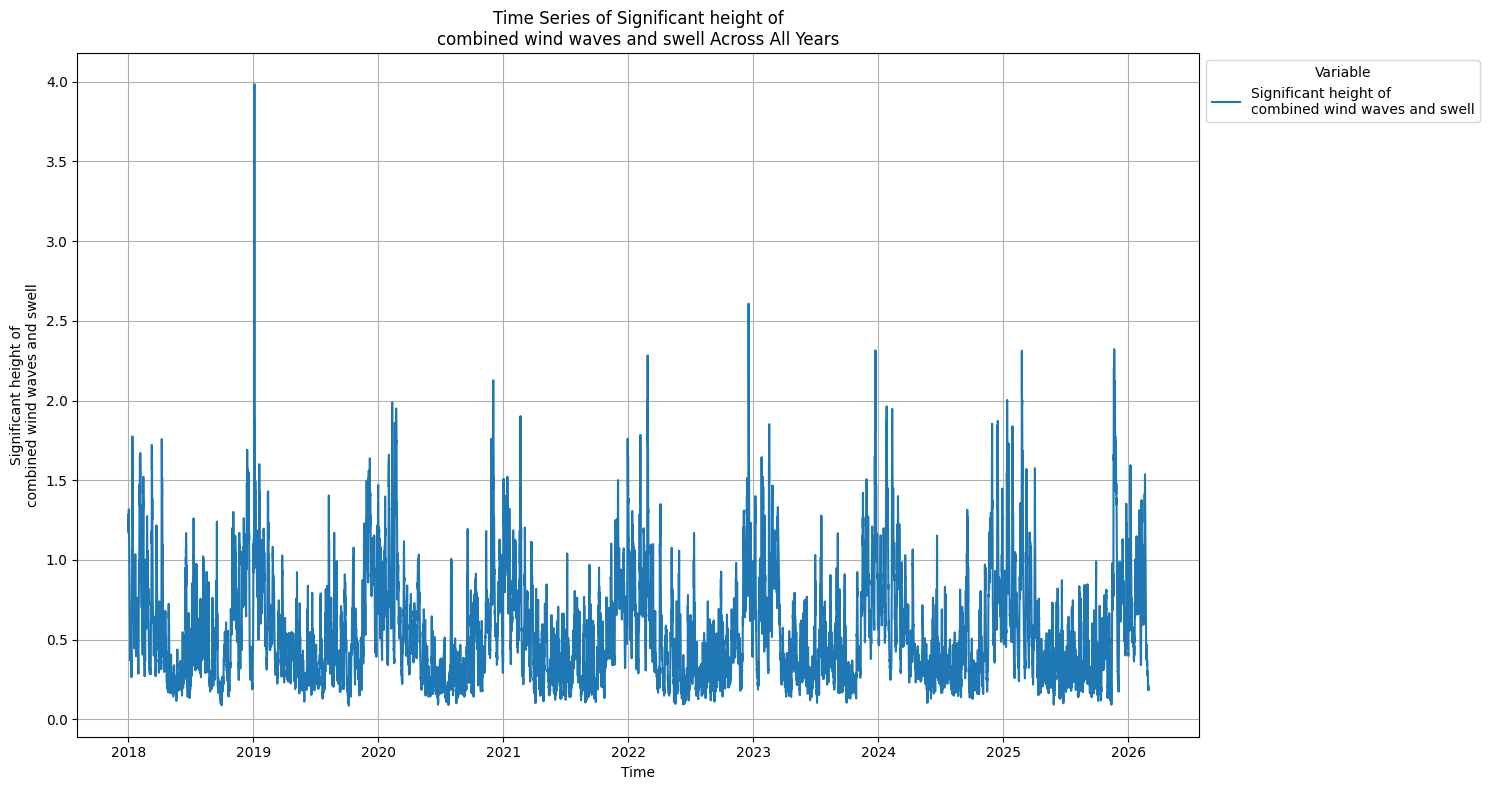

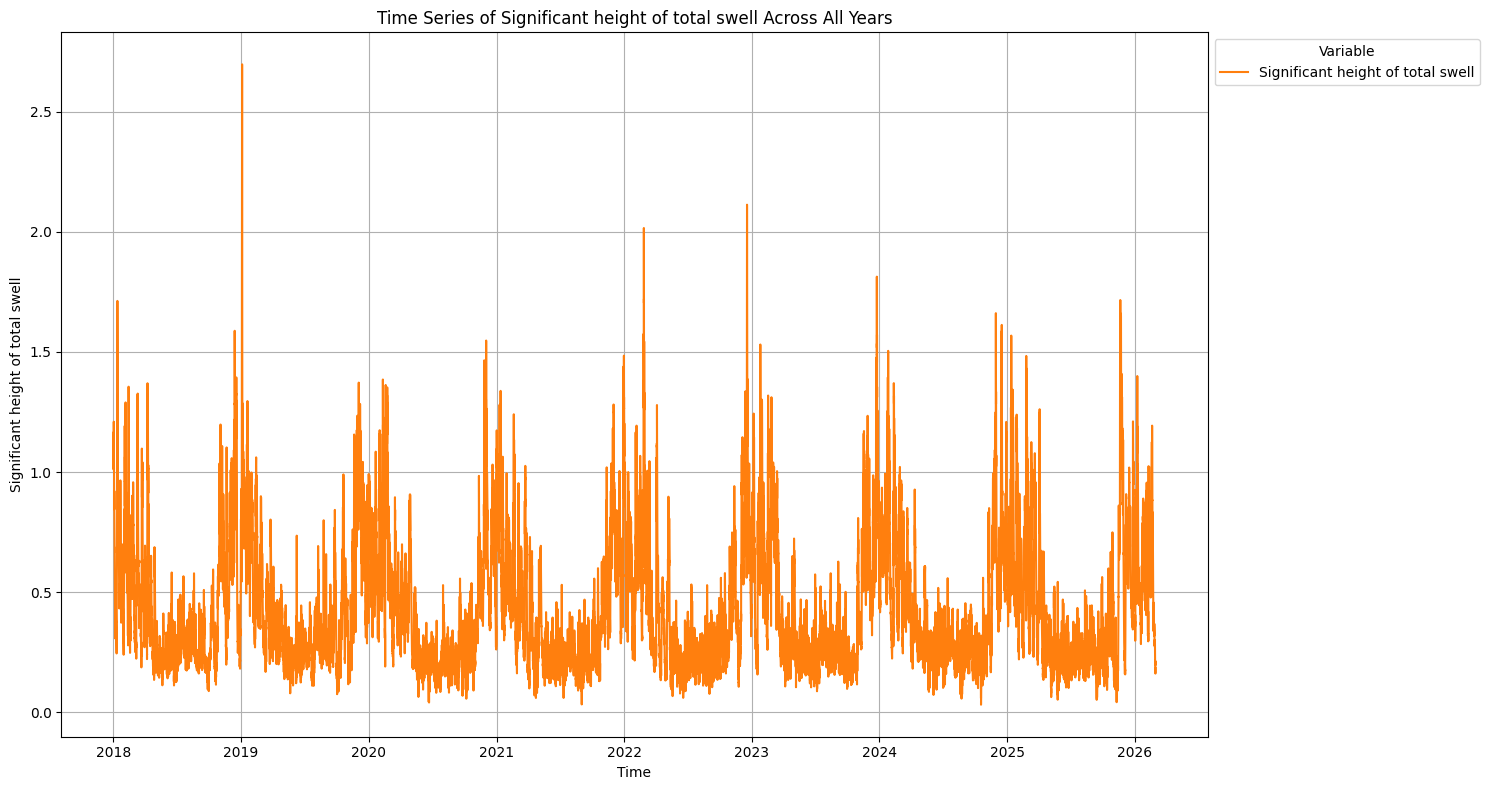

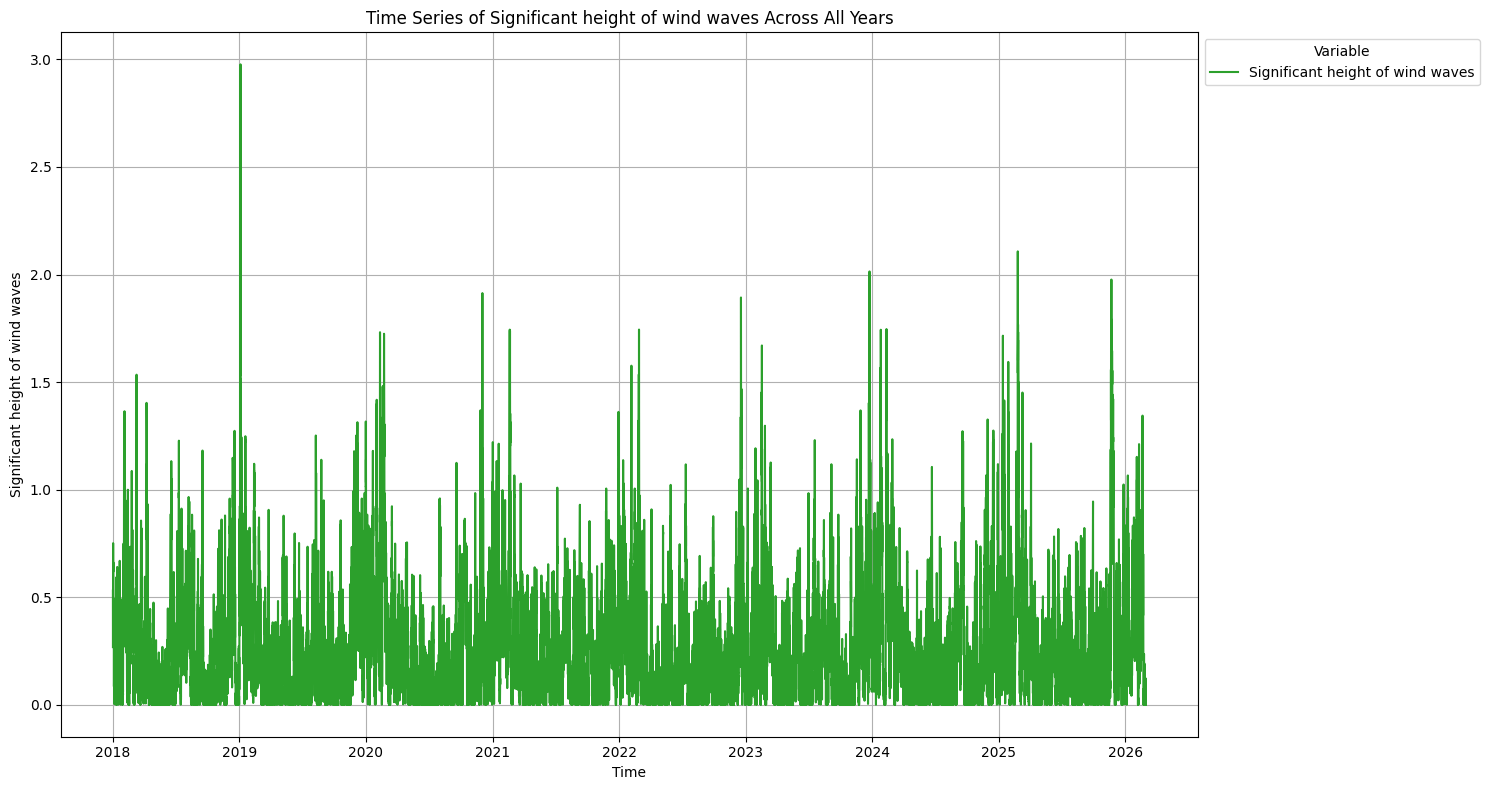

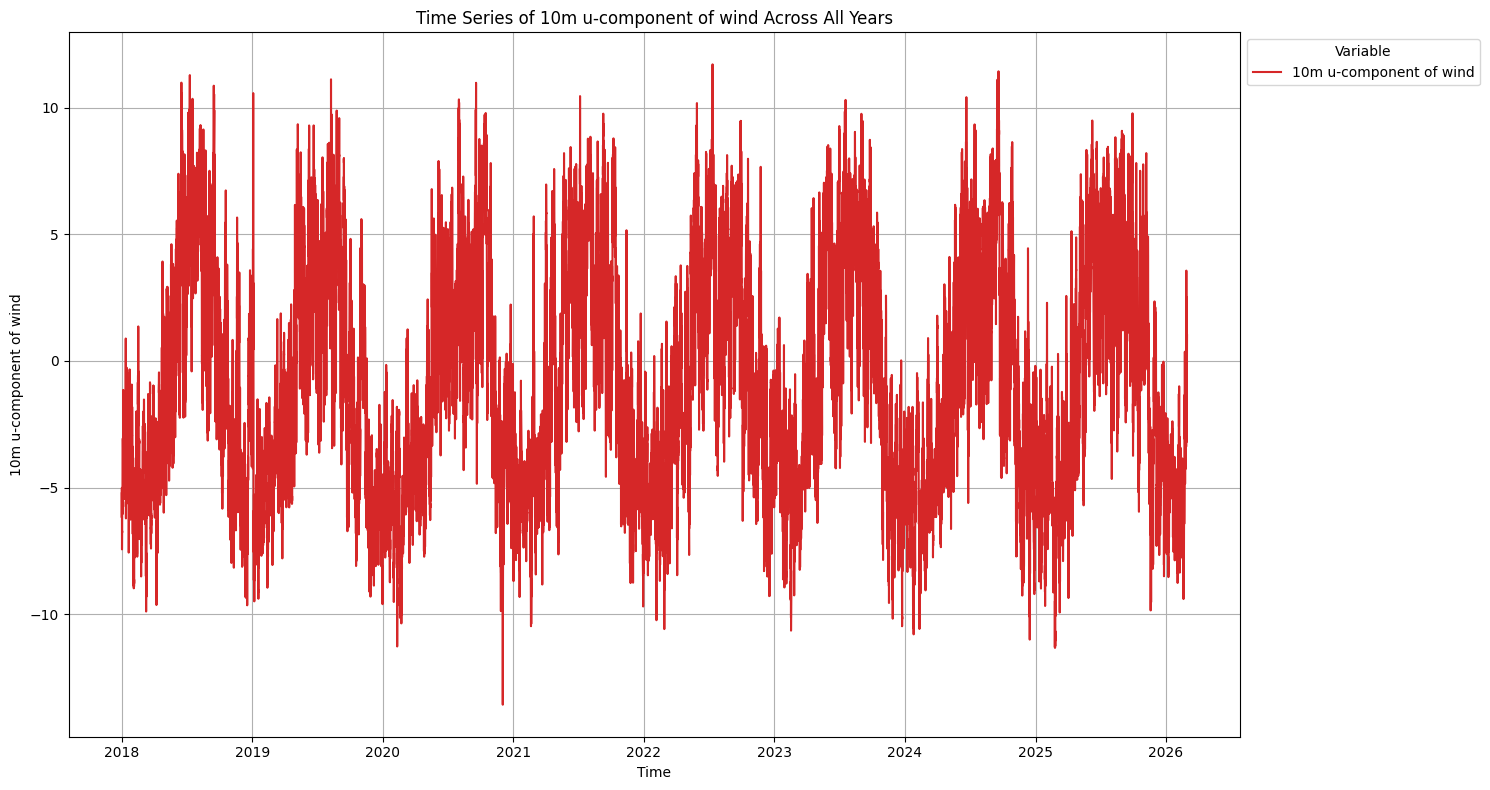

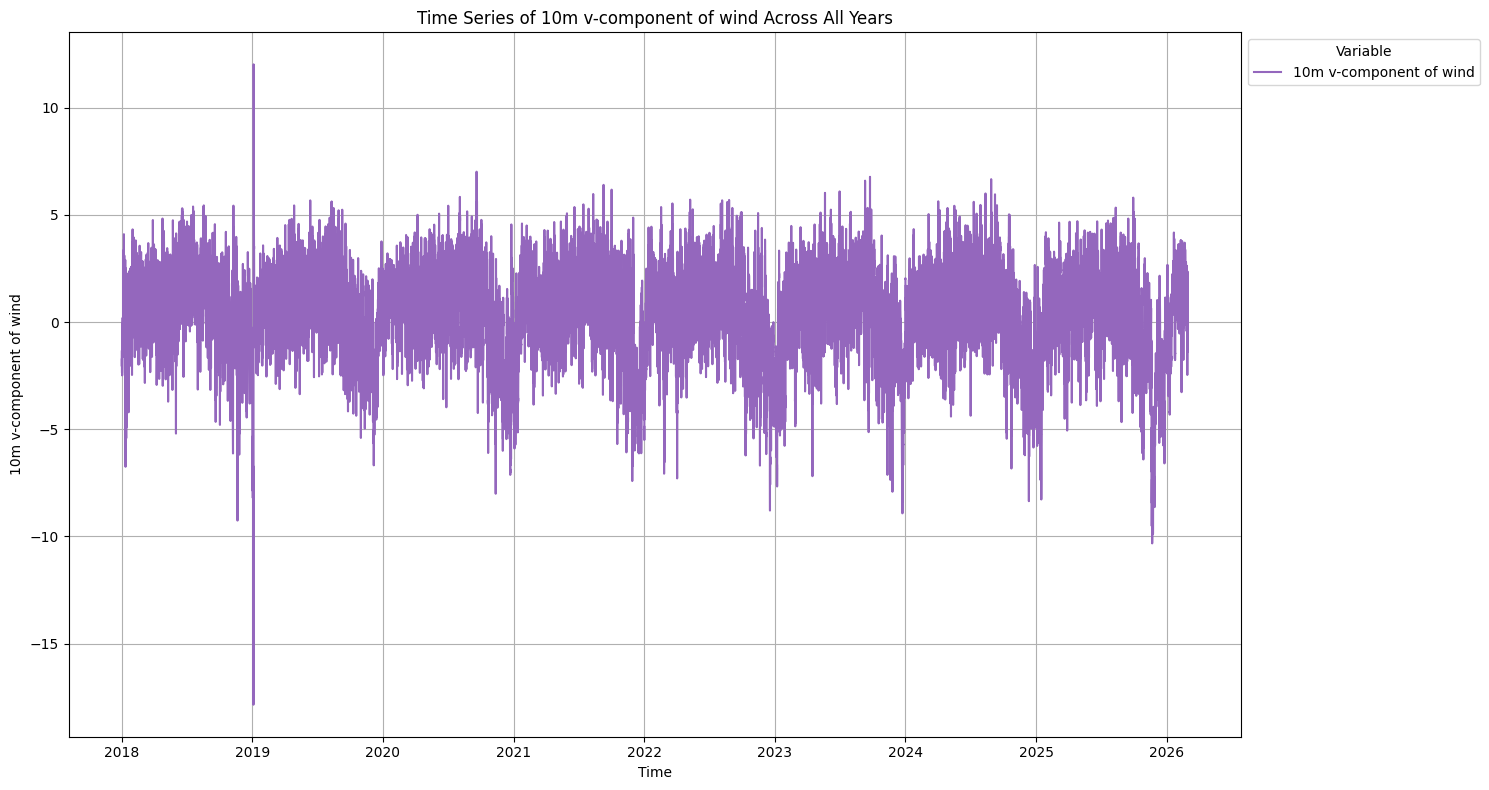

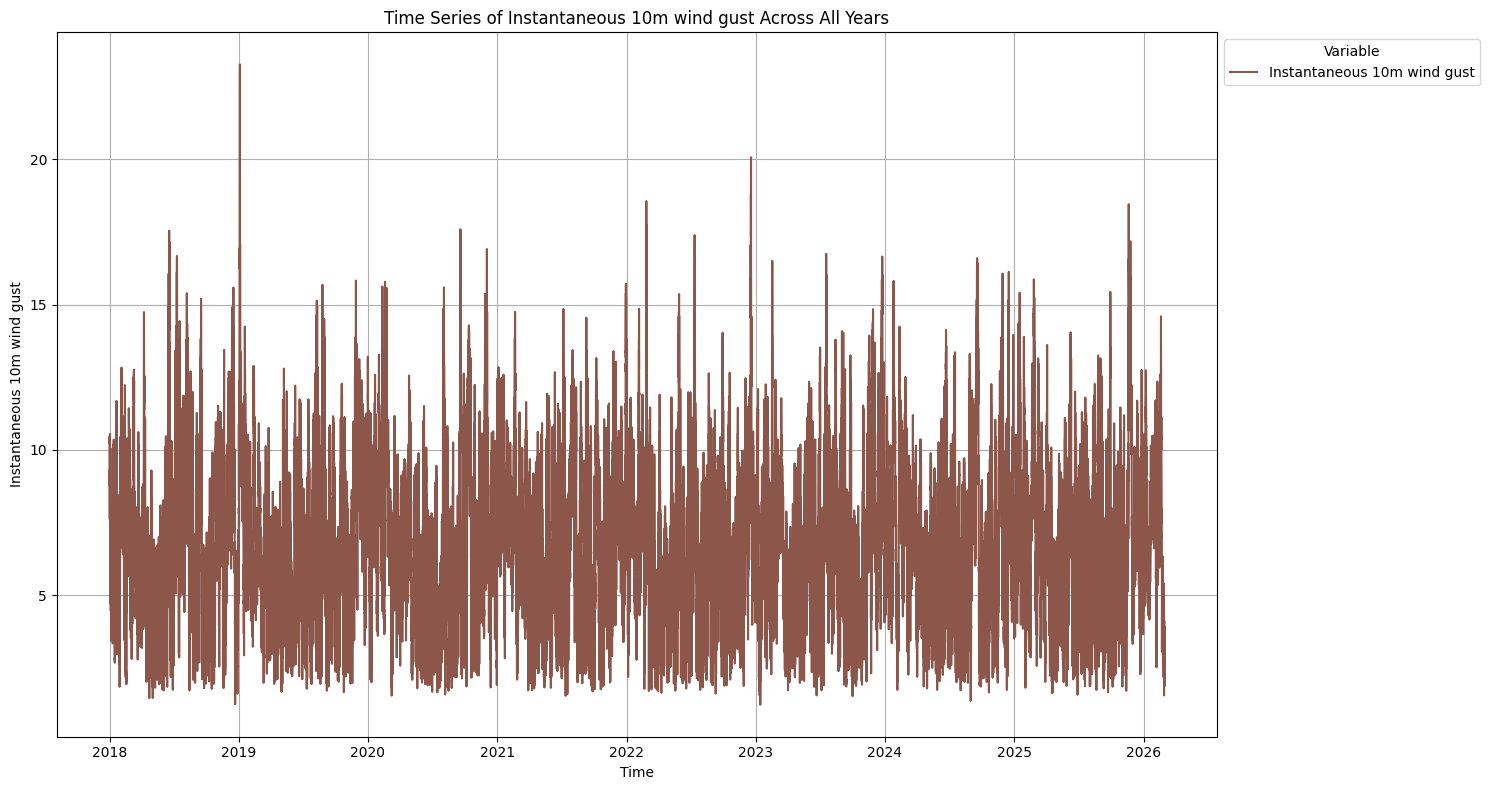

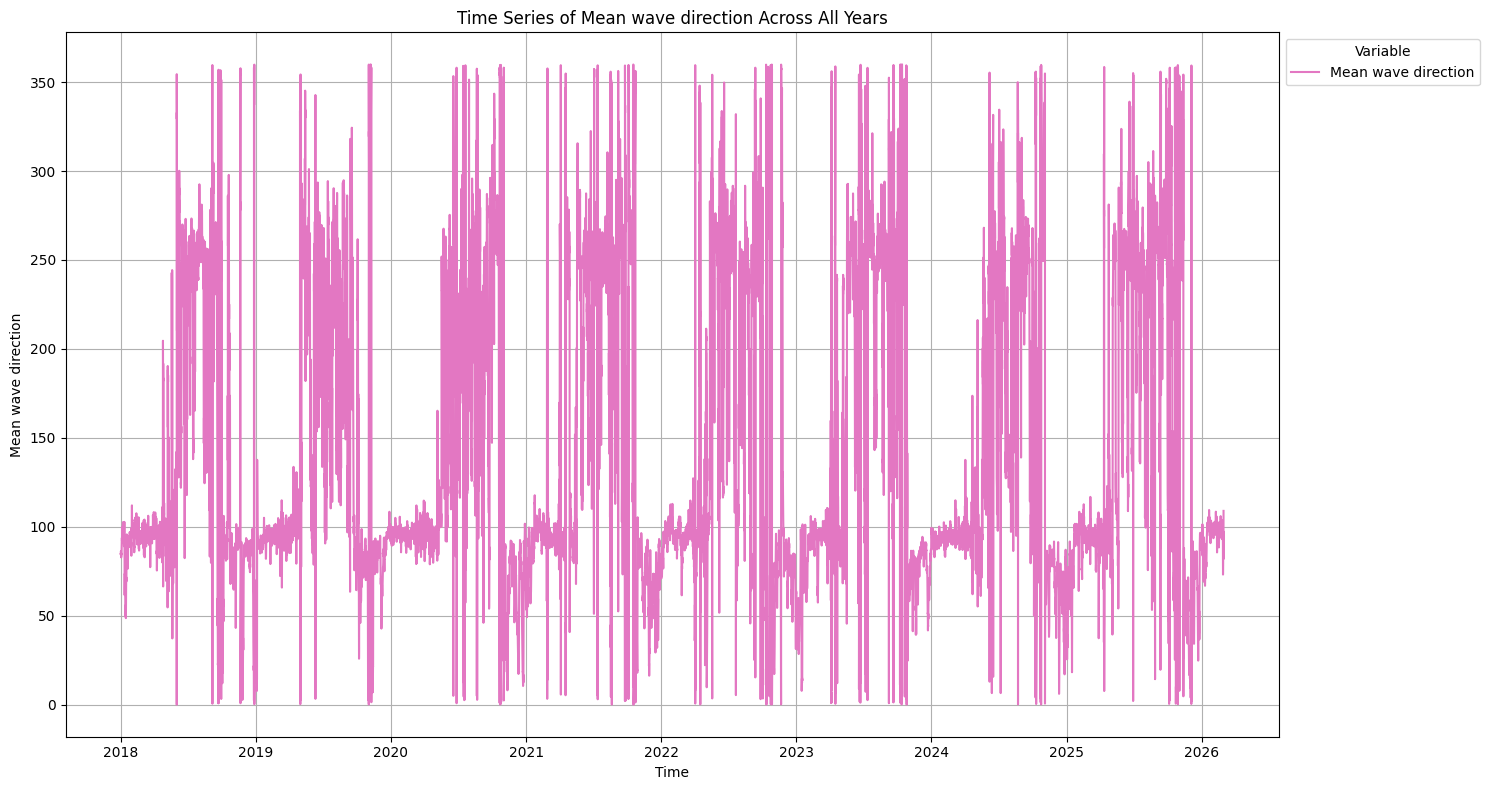

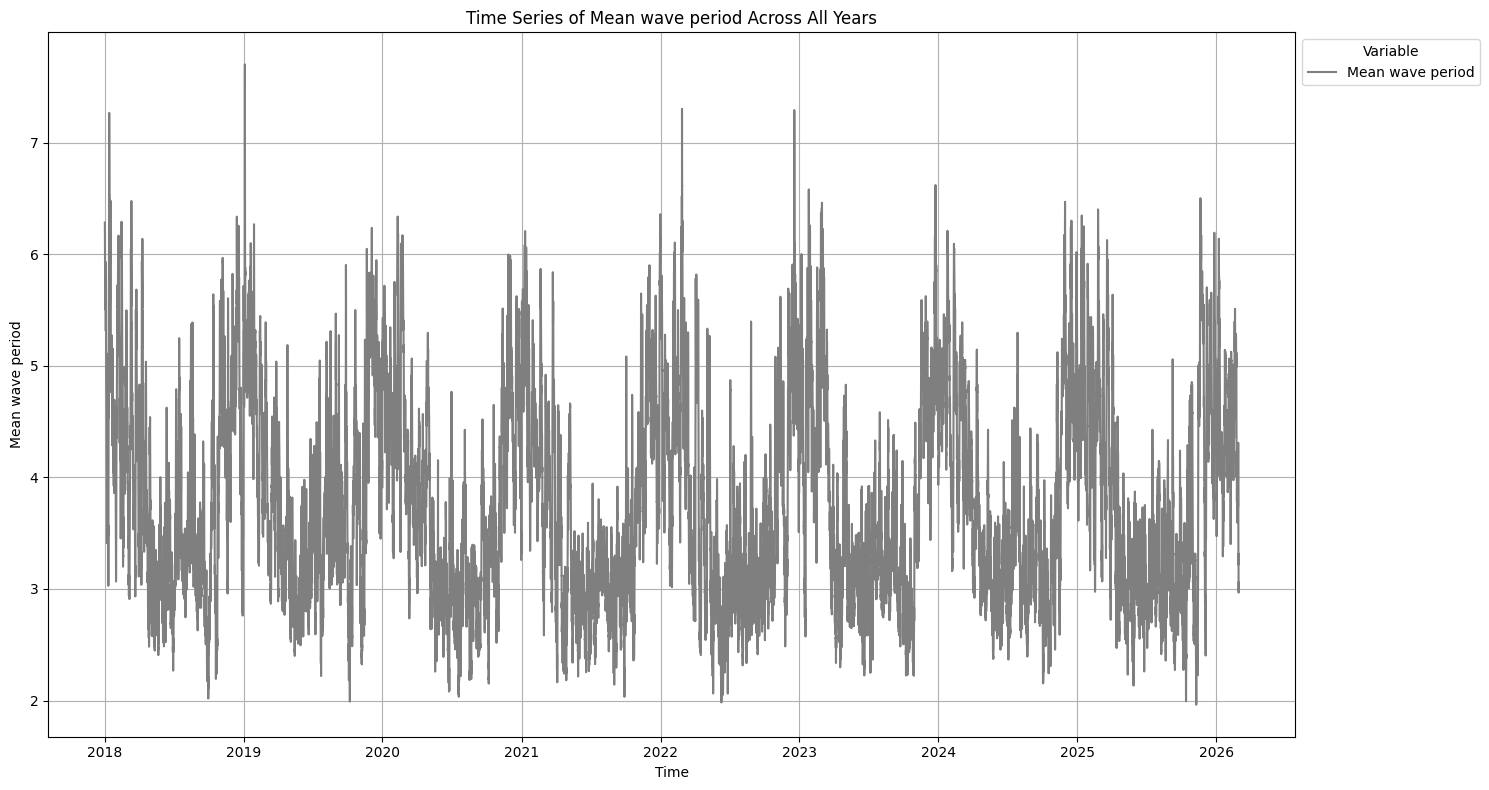

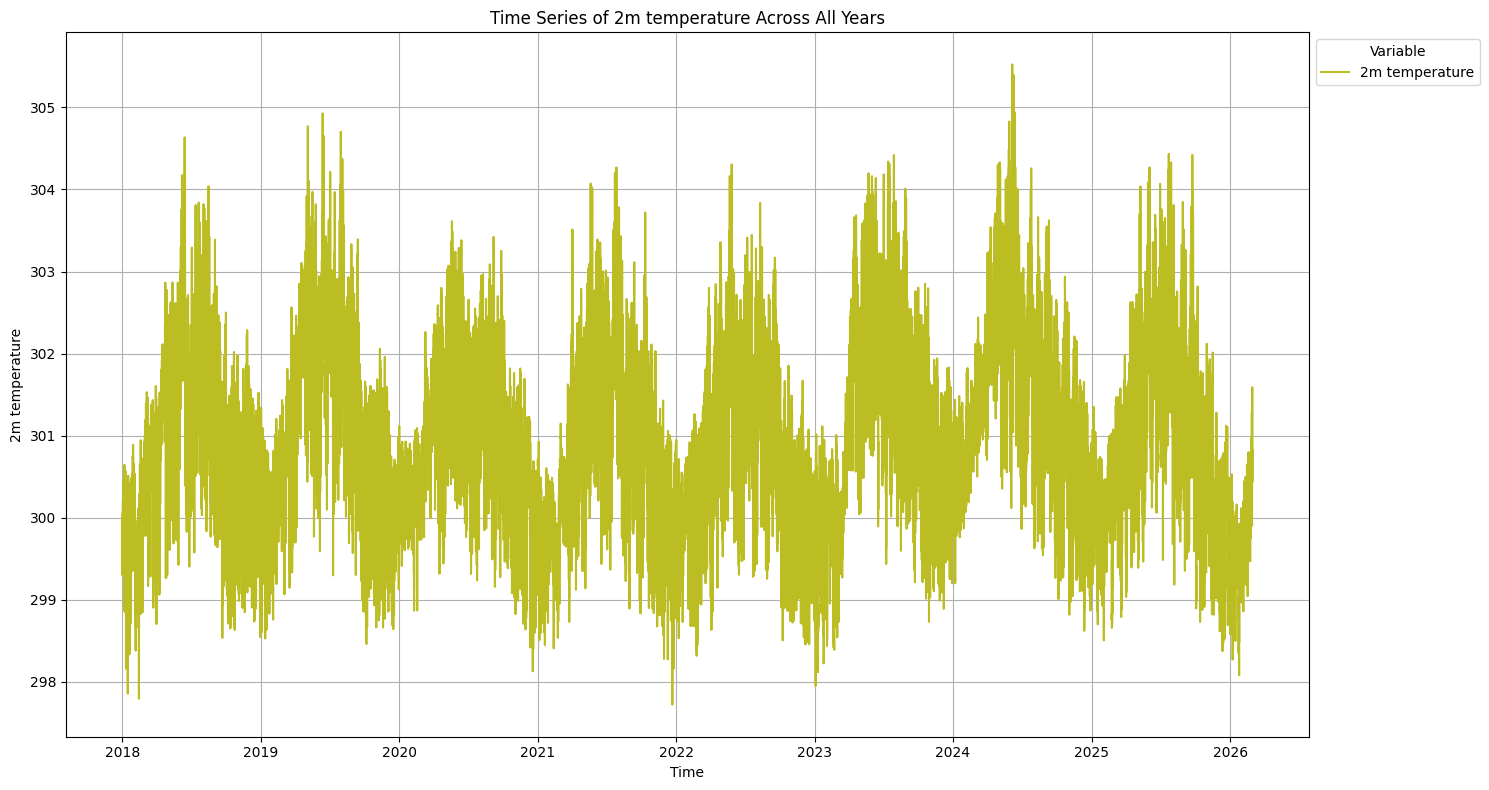

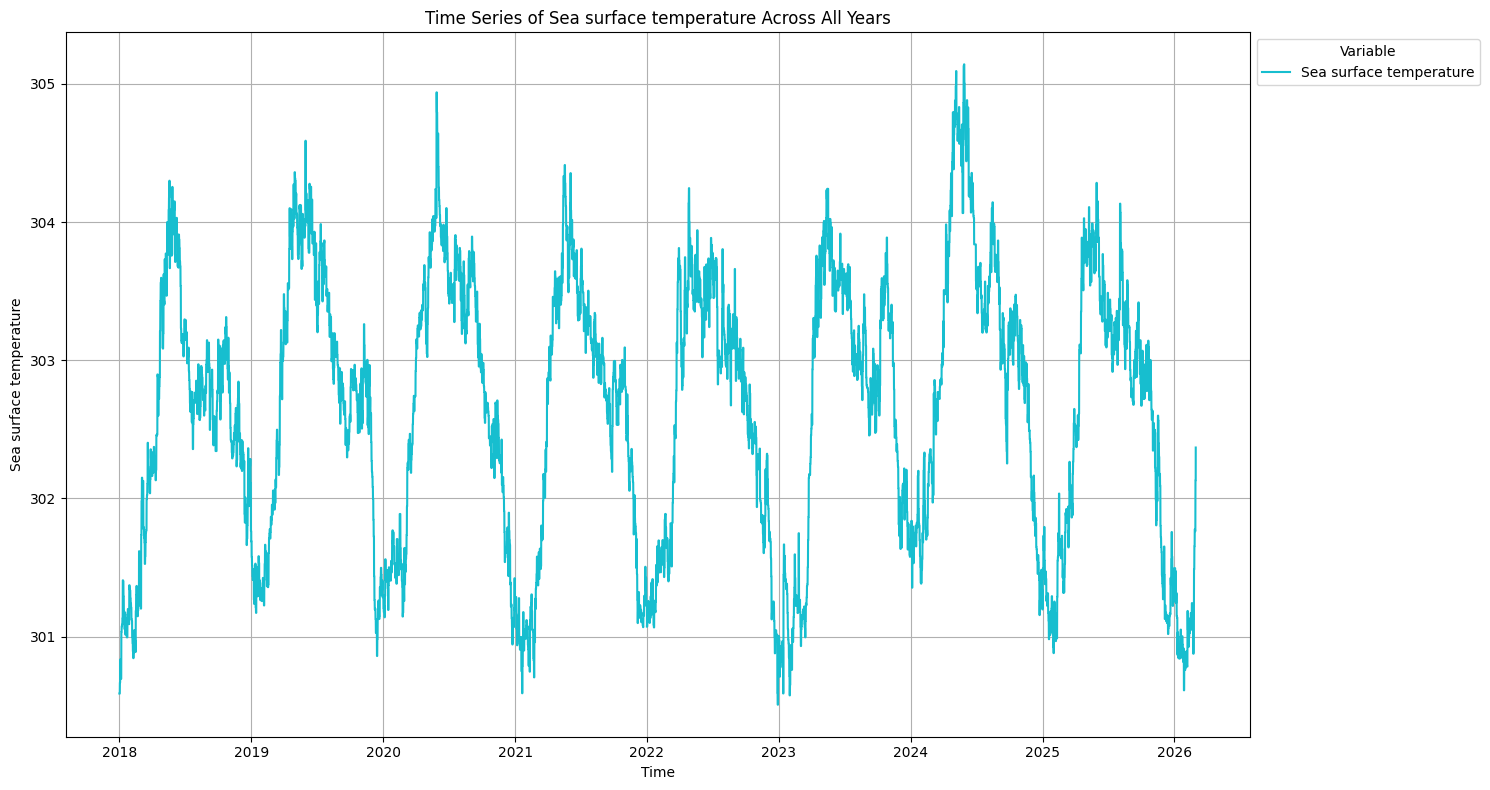

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting
numerical_cols = HuasaiNakhonThammarat_indexed.select_dtypes(include=['float64', 'int64']).columns

# Get unique years from the index
years = HuasaiNakhonThammarat_indexed.index.year.unique()

# Plot each numerical column separately, with all years in the same color
for col in numerical_cols:
    plt.figure(figsize=(15, 8))
    for year in years:
        data_yearly = HuasaiNakhonThammarat_indexed[HuasaiNakhonThammarat_indexed.index.year == year]
        plt.plot(data_yearly.index, data_yearly[col], color=plt.cm.tab10(numerical_cols.get_loc(col)), label=col if year == years[0] else "_nolegend_") # Use the first year's plot for the legend

    plt.title(f'Time Series of {col} Across All Years')
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.legend(title='Variable', loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

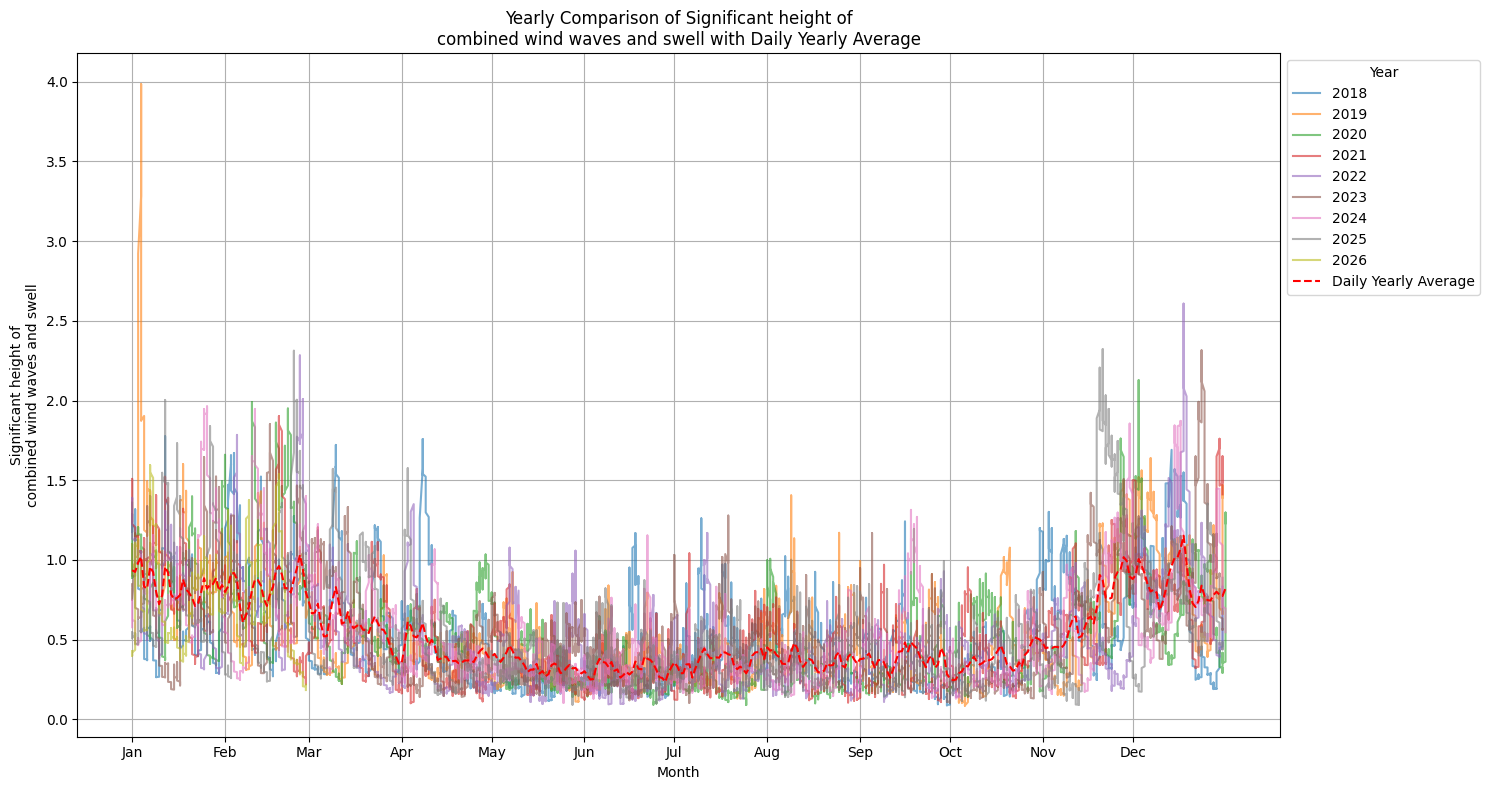

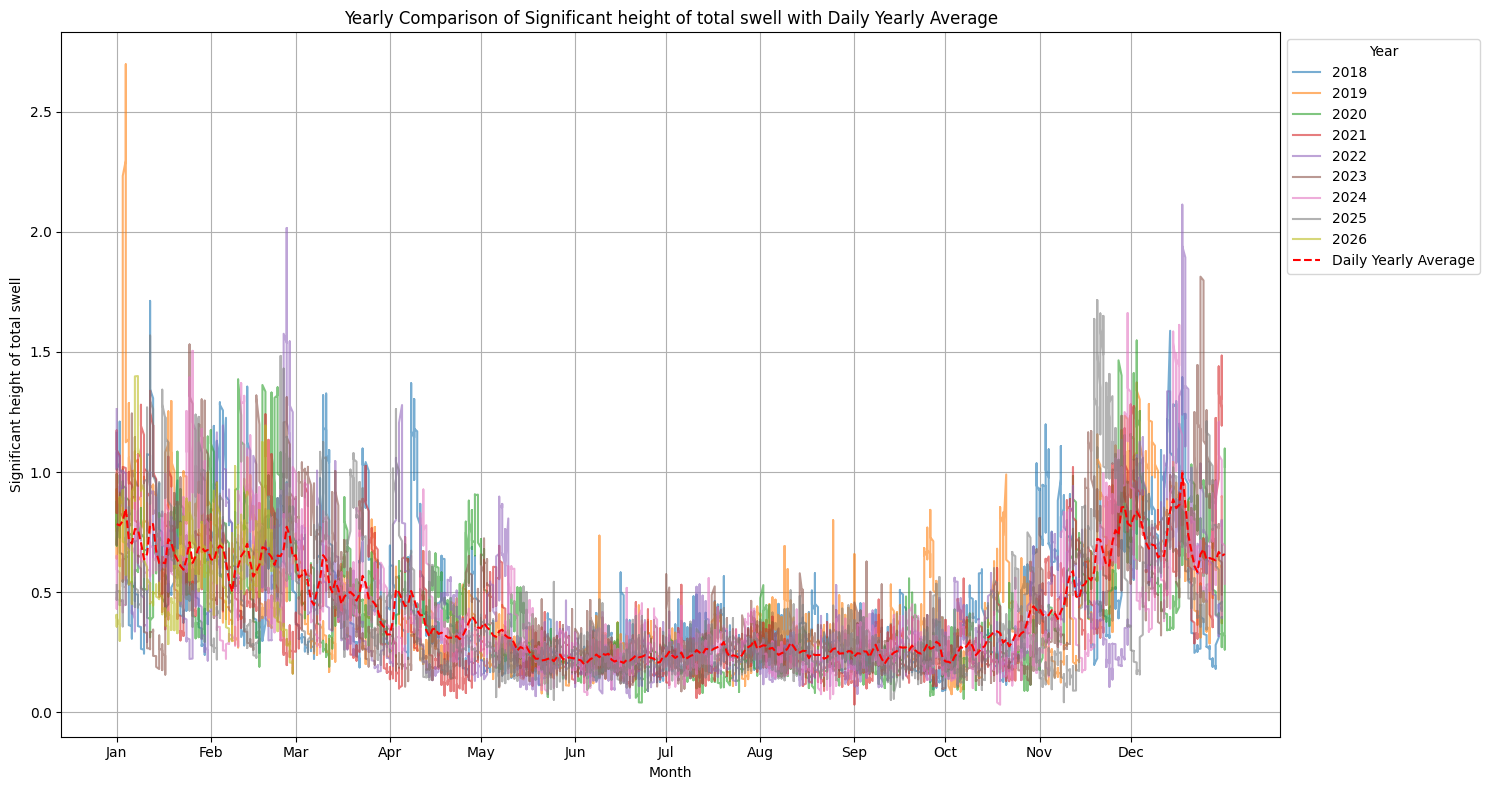

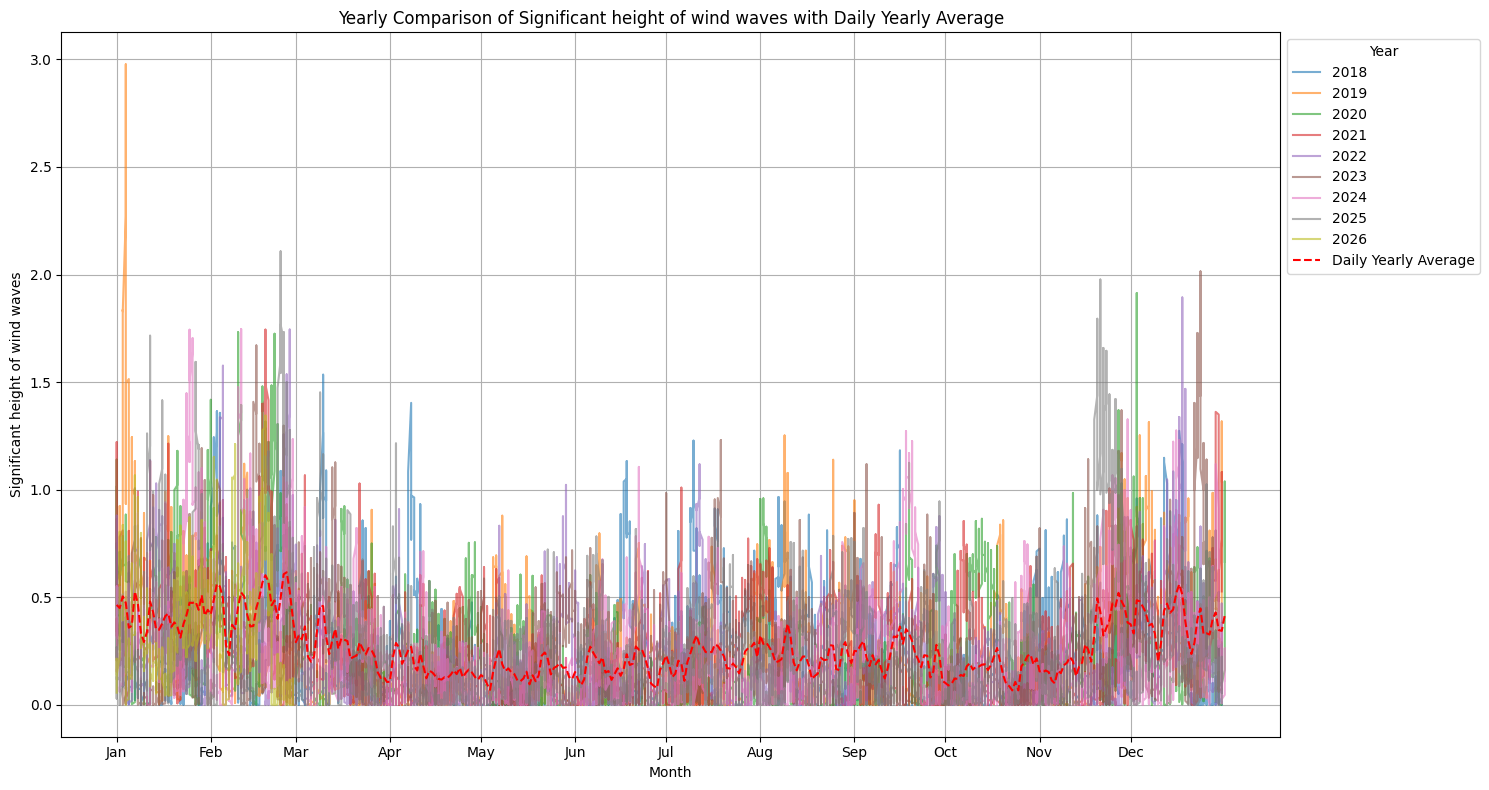

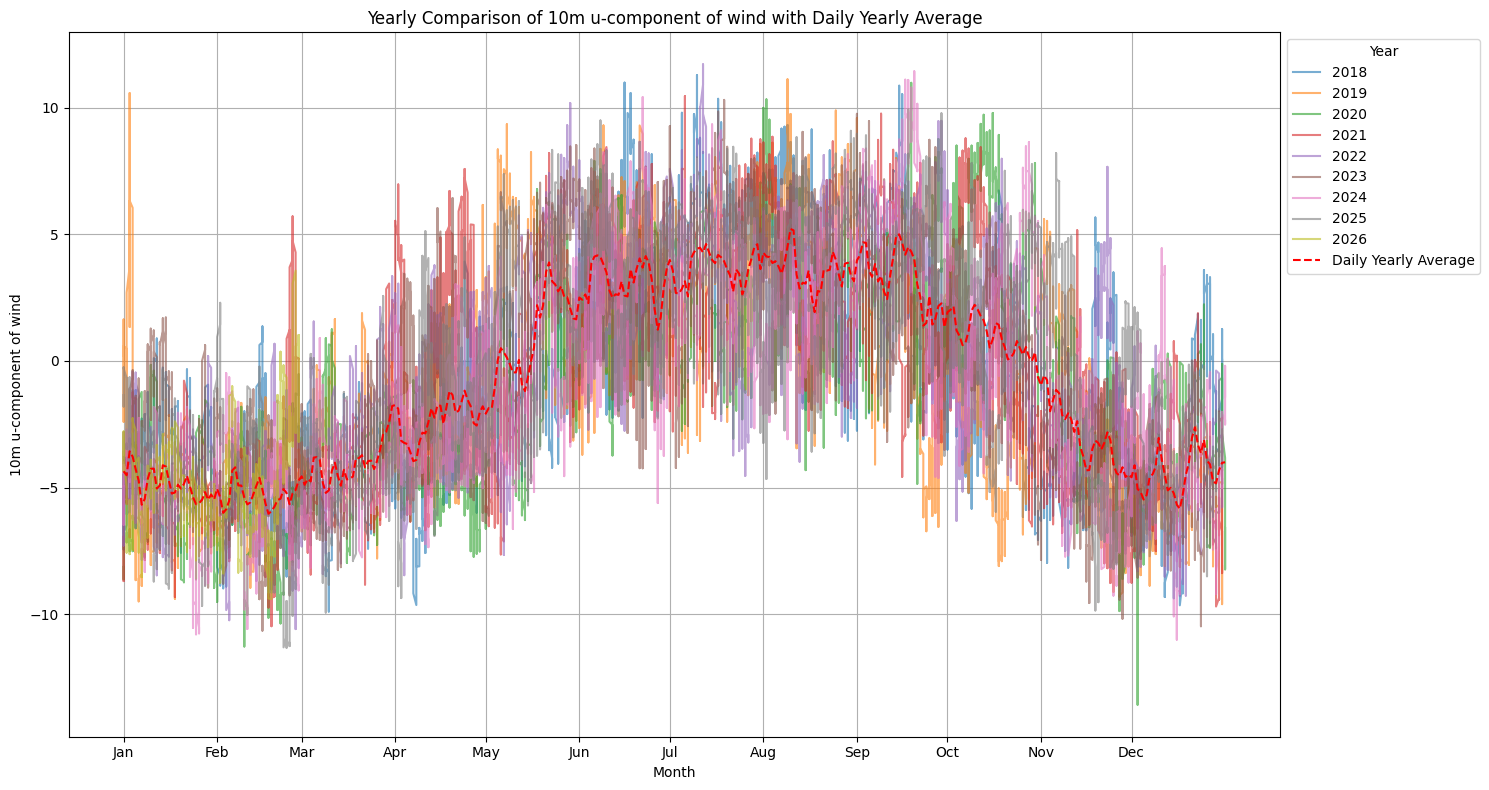

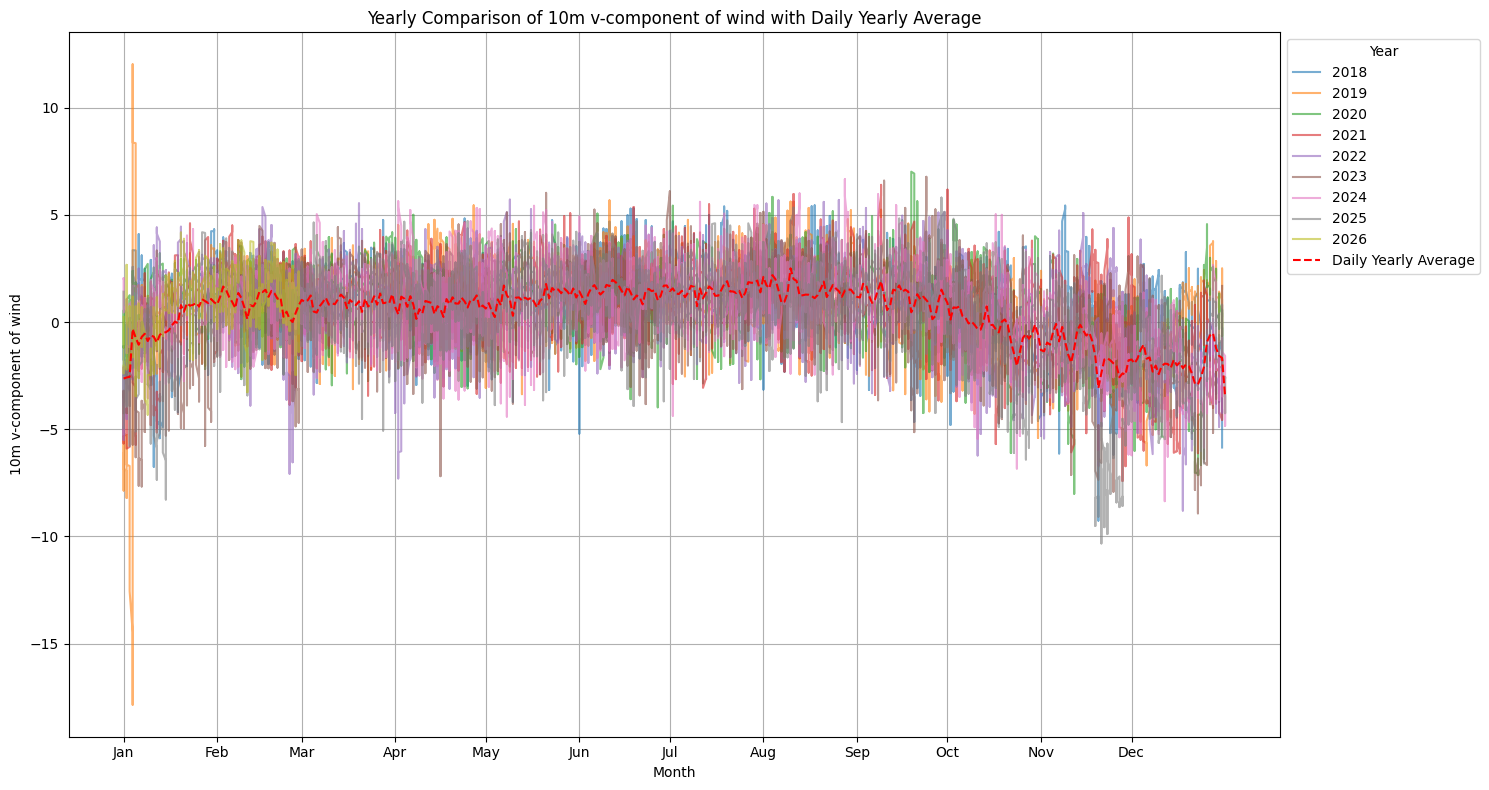

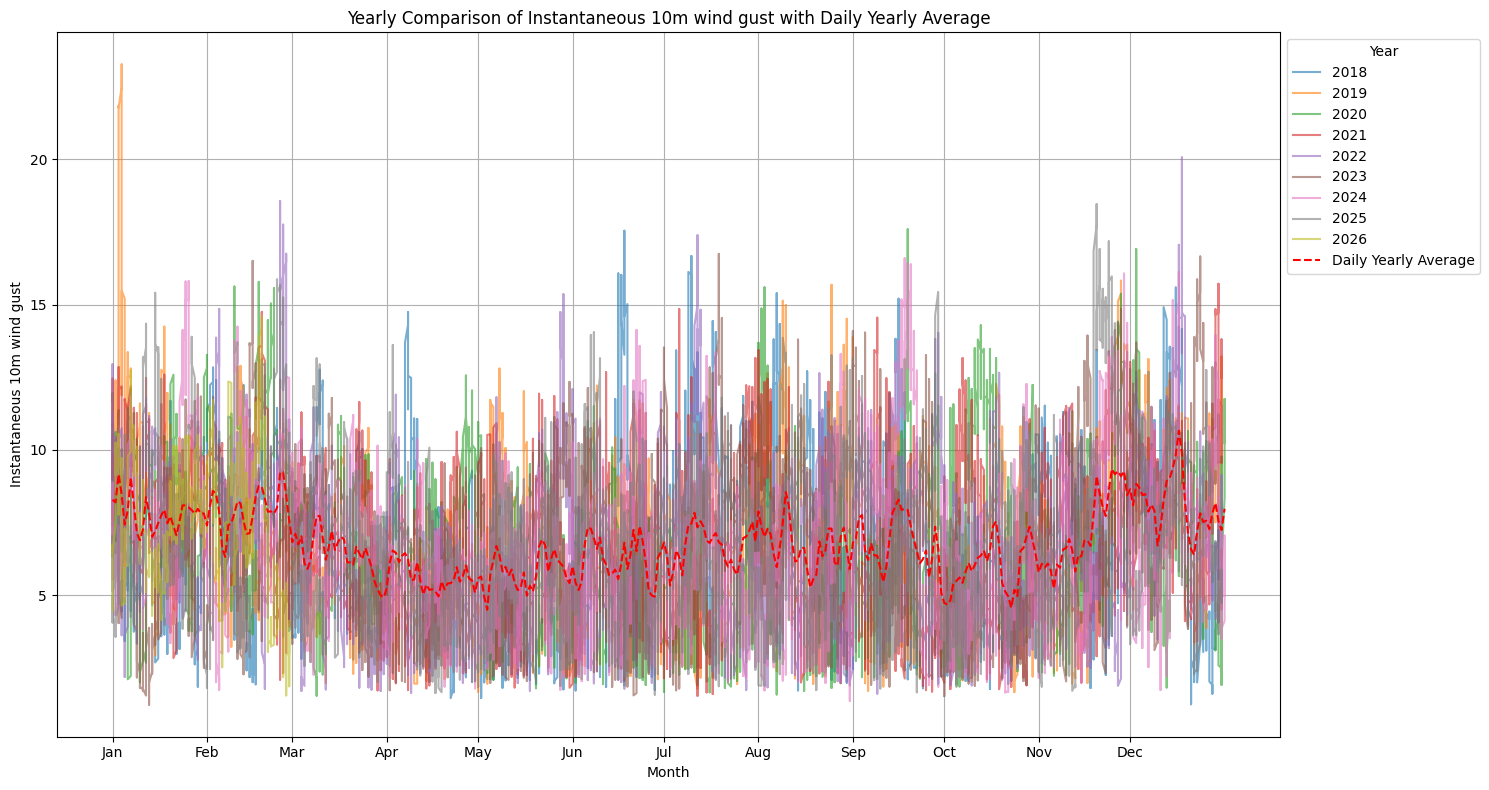

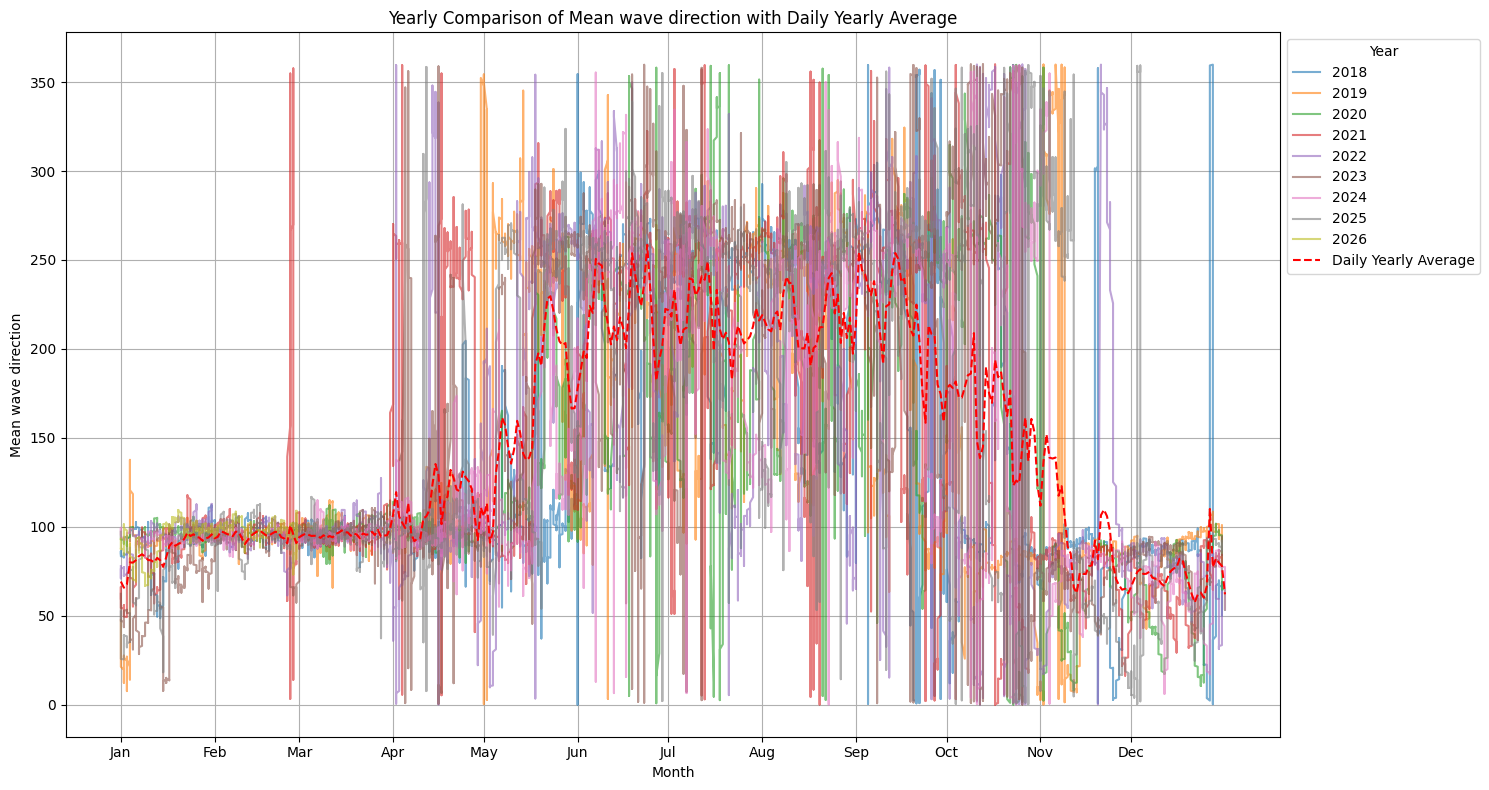

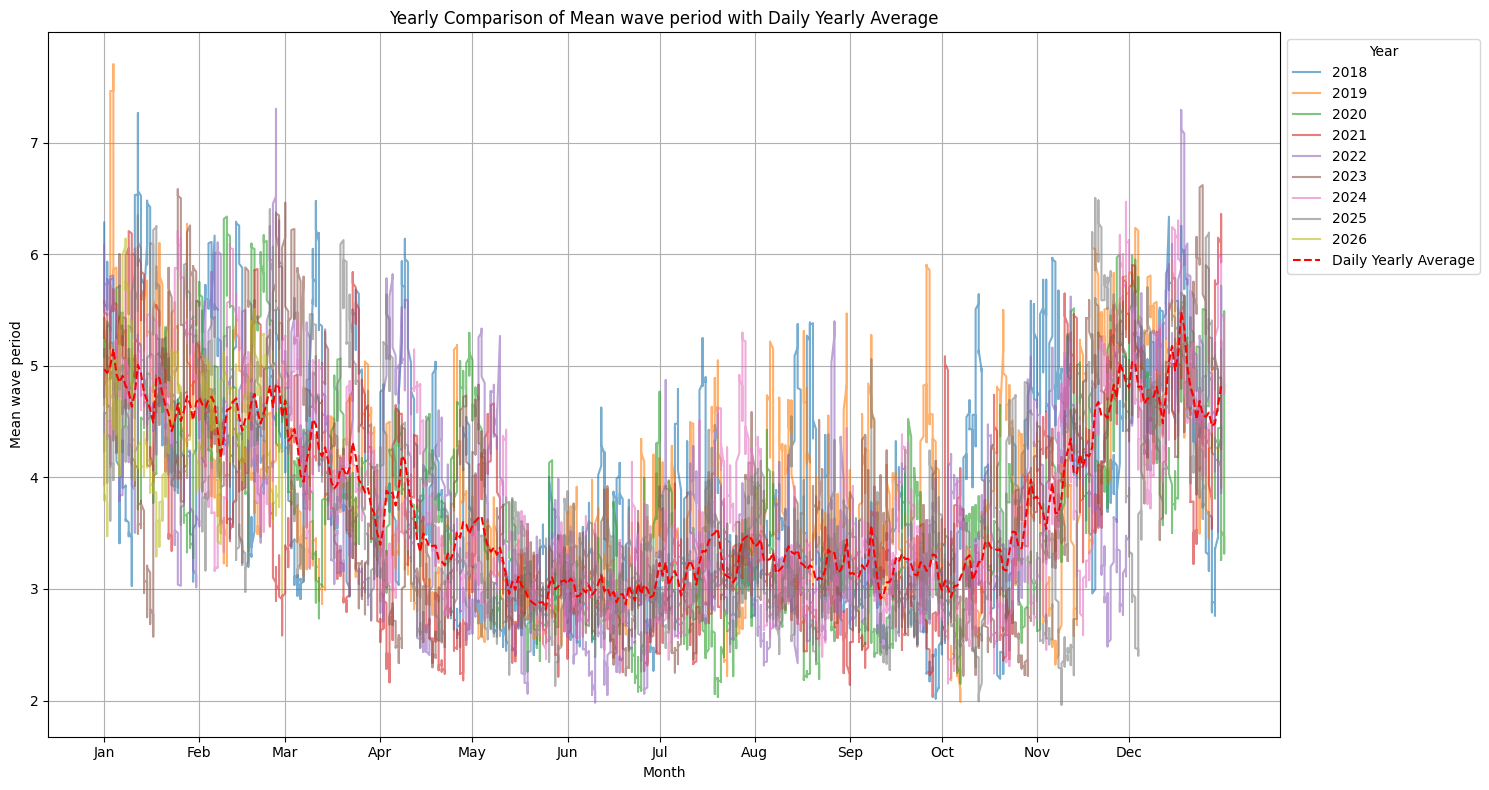

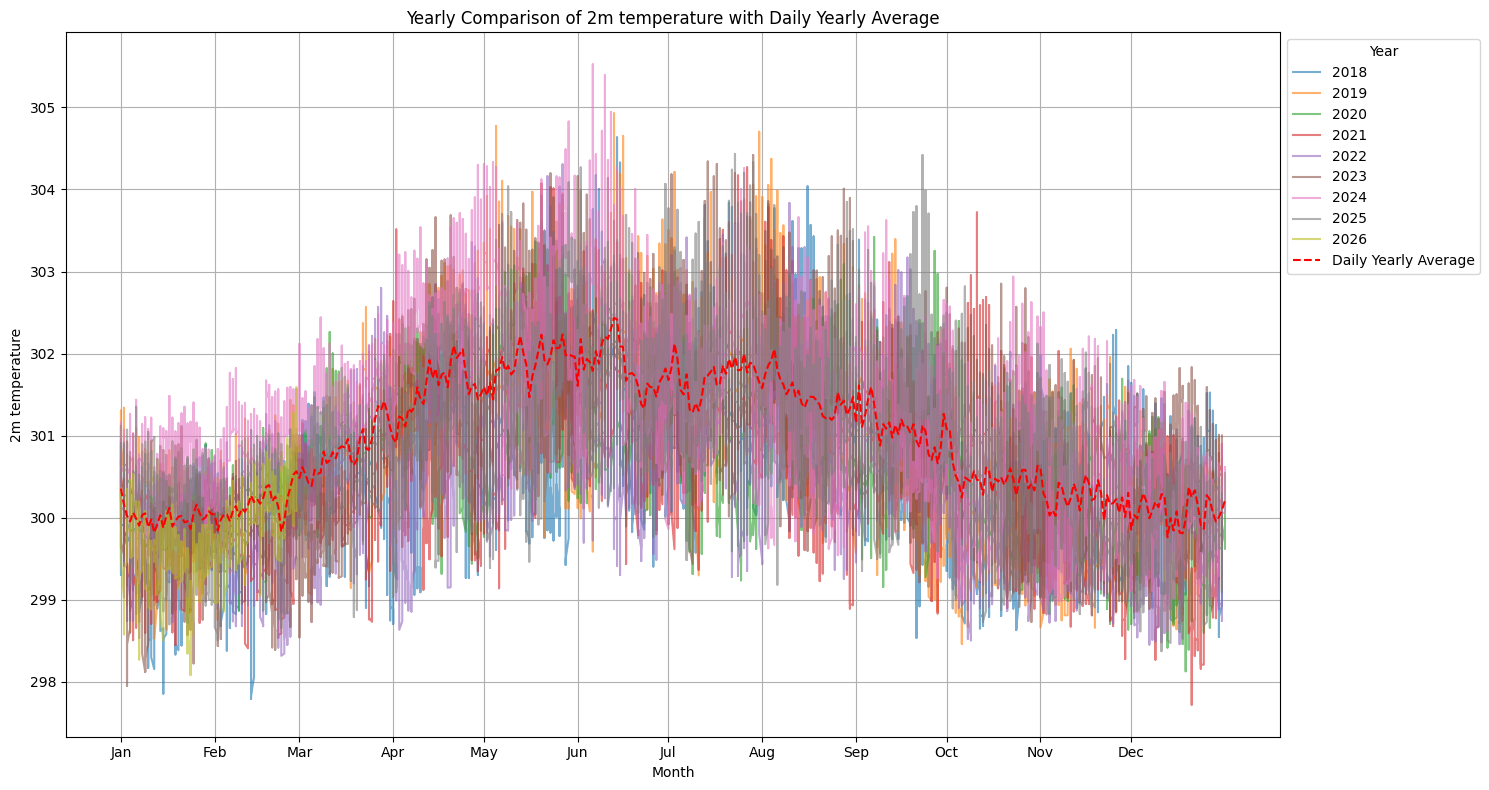

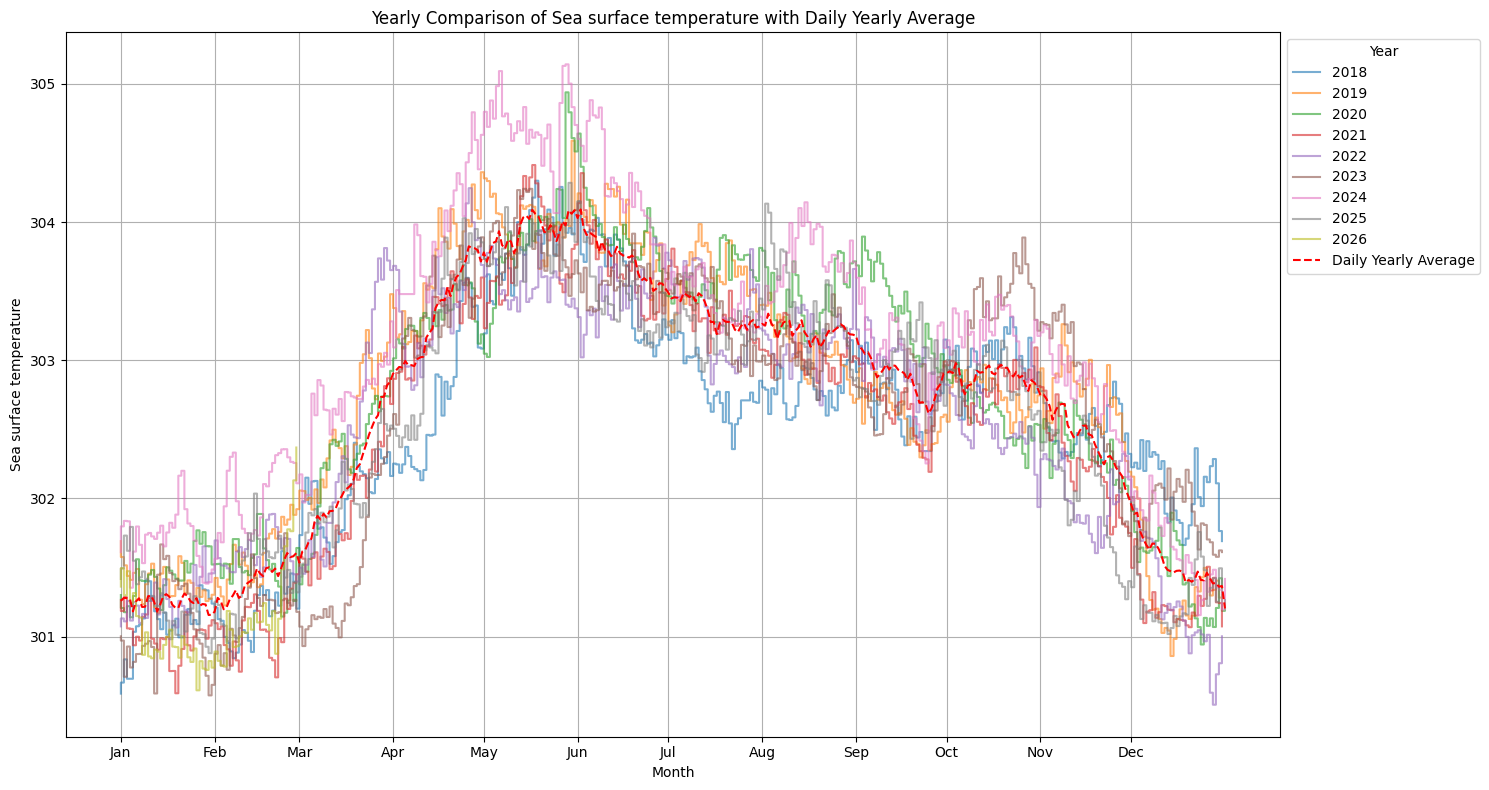

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np # Import numpy for calculations

# เลือกคอลัมน์ตัวเลขสำหรับการพล็อต
numerical_cols = HuasaiNakhonThammarat_indexed.select_dtypes(include=['float64', 'int64']).columns

# Get unique years from the index
years = HuasaiNakhonThammarat_indexed.index.year.unique()

# Add 'day_of_year' to the original indexed DataFrame for easier calculation of daily average
HuasaiNakhonThammarat_indexed['day_of_year'] = HuasaiNakhonThammarat_indexed.index.dayofyear

# Calculate the average for each day of the year across all years
# Group by 'day_of_year' and calculate the mean for each numerical column
daily_yearly_average = HuasaiNakhonThammarat_indexed.groupby('day_of_year')[numerical_cols].mean()


# พล็อตแต่ละคอลัมน์ตัวเลขแยกกัน โดยให้แต่ละปีเป็นบรรทัดแยกกัน
for col in numerical_cols:
    plt.figure(figsize=(15, 8))

    for year in years:
        # กรองข้อมูลสำหรับปีปัจจุบัน
        data_yearly = HuasaiNakhonThammarat_indexed[HuasaiNakhonThammarat_indexed.index.year == year].copy()

        # Plot the data using the day of the year for the x-axis
        plt.plot(data_yearly['day_of_year'], data_yearly[col], label=year, alpha=0.6) # Added alpha for better visibility of individual years

    # Plot the daily yearly average line in red
    # Ensure the index of daily_yearly_average is used for the x-axis
    plt.plot(daily_yearly_average.index, daily_yearly_average[col], color='red', linestyle='--', label=f'Daily Yearly Average')


    plt.title(f'Yearly Comparison of {col} with Daily Yearly Average')
    plt.xlabel('Month') # Change xlabel to Month
    plt.ylabel(col)
    plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)

    # Set x-axis major locator and formatter to show months correctly
    ax = plt.gca()
    # Define the positions of the ticks based on the day of the year for the start of each month
    # This is an approximation; for more accuracy, consider leap years and exact days in months
    month_starts_dayofyear = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335] # Approximate start day of year for each month (non-leap year)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.xaxis.set_major_locator(plt.FixedLocator(month_starts_dayofyear))
    ax.xaxis.set_major_formatter(plt.FixedFormatter(month_names))


    plt.tight_layout()
    plt.show()

ยกตัวอย่างรูปแรก จะเห็นว่าในแต่ละปี เส้นของความสูงคลื่นมีรูปแบบการเปลี่ยนแปลง โดยทั่วไปแล้ว:
- ความสูงคลื่นมักจะ ขึ้นลง ในช่วงต้นปี (ประมาณ มกราคม - เมษายน)
- ความสูงคลื่นจะเริ่ม ต่ำ ในช่วงกลางปี (ประมาณ พฤษภาคม - ตุลาคม)
- จากนั้นความสูงคลื่นจะเริ่ม สูงขึ้น อีกครั้งในช่วงปลายปี (ประมาณ พฤศจิกายน - ธันวาคม)


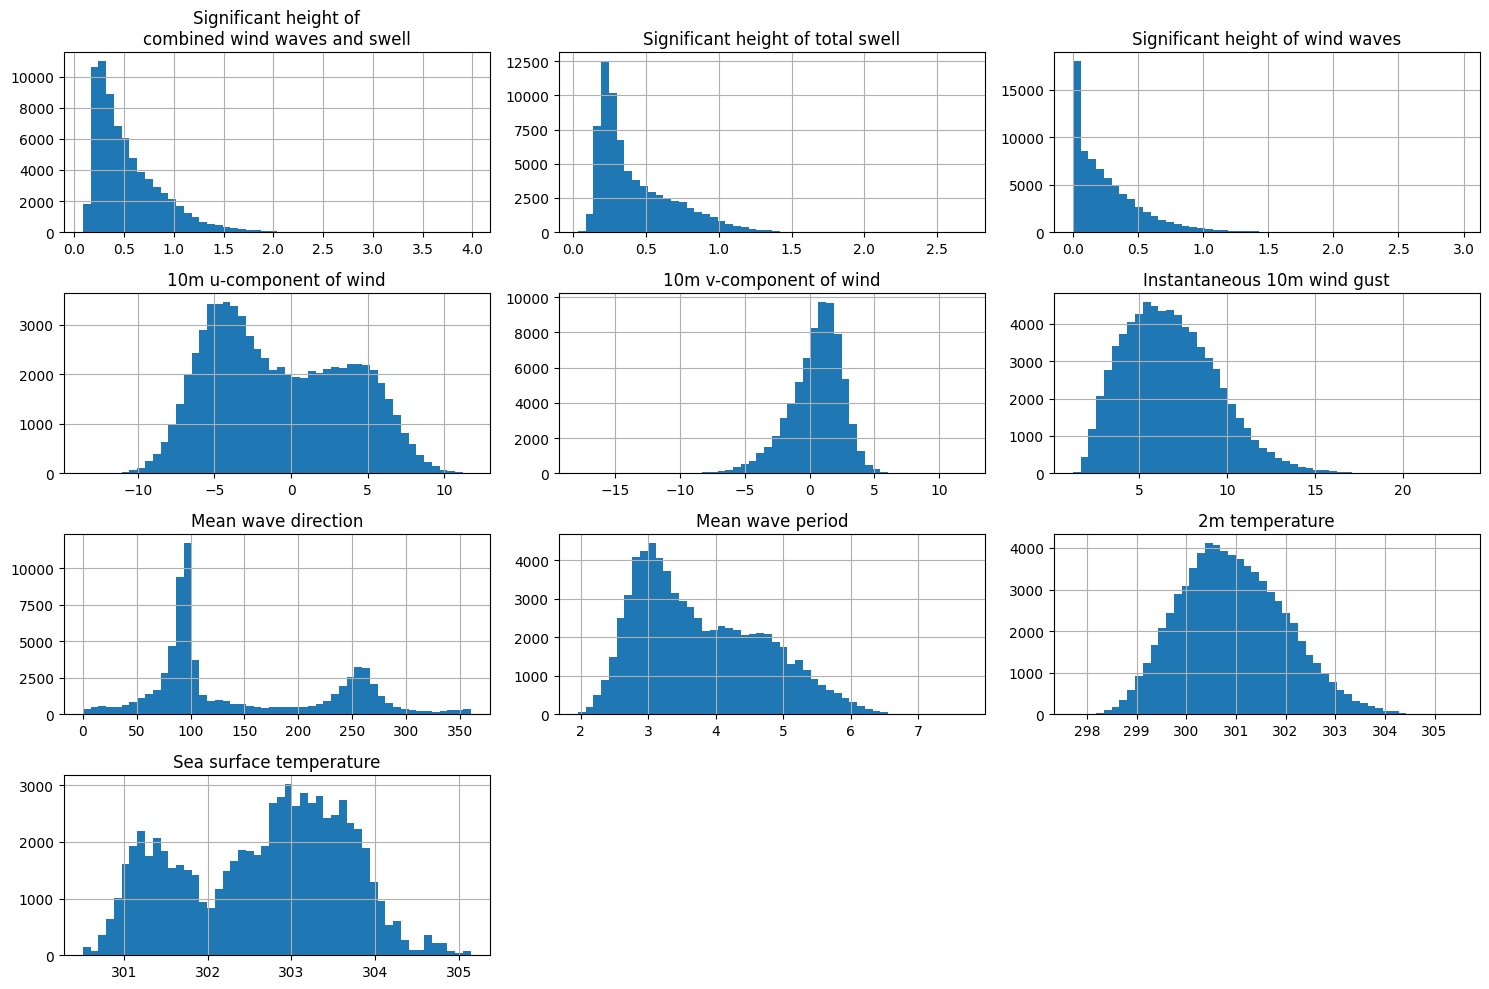

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting distribution
numerical_cols = HuasaiNakhonThammarat_indexed.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for numerical columns
HuasaiNakhonThammarat_indexed[numerical_cols].hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

# Alternatively, plot box plots to see distribution and outliers
# fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, len(numerical_cols)*4))
# for i, col in enumerate(numerical_cols):
#     sns.boxplot(x=HuasaiNakhonThammarat_indexed[col], ax=axes[i])
# plt.tight_layout()
# plt.show()

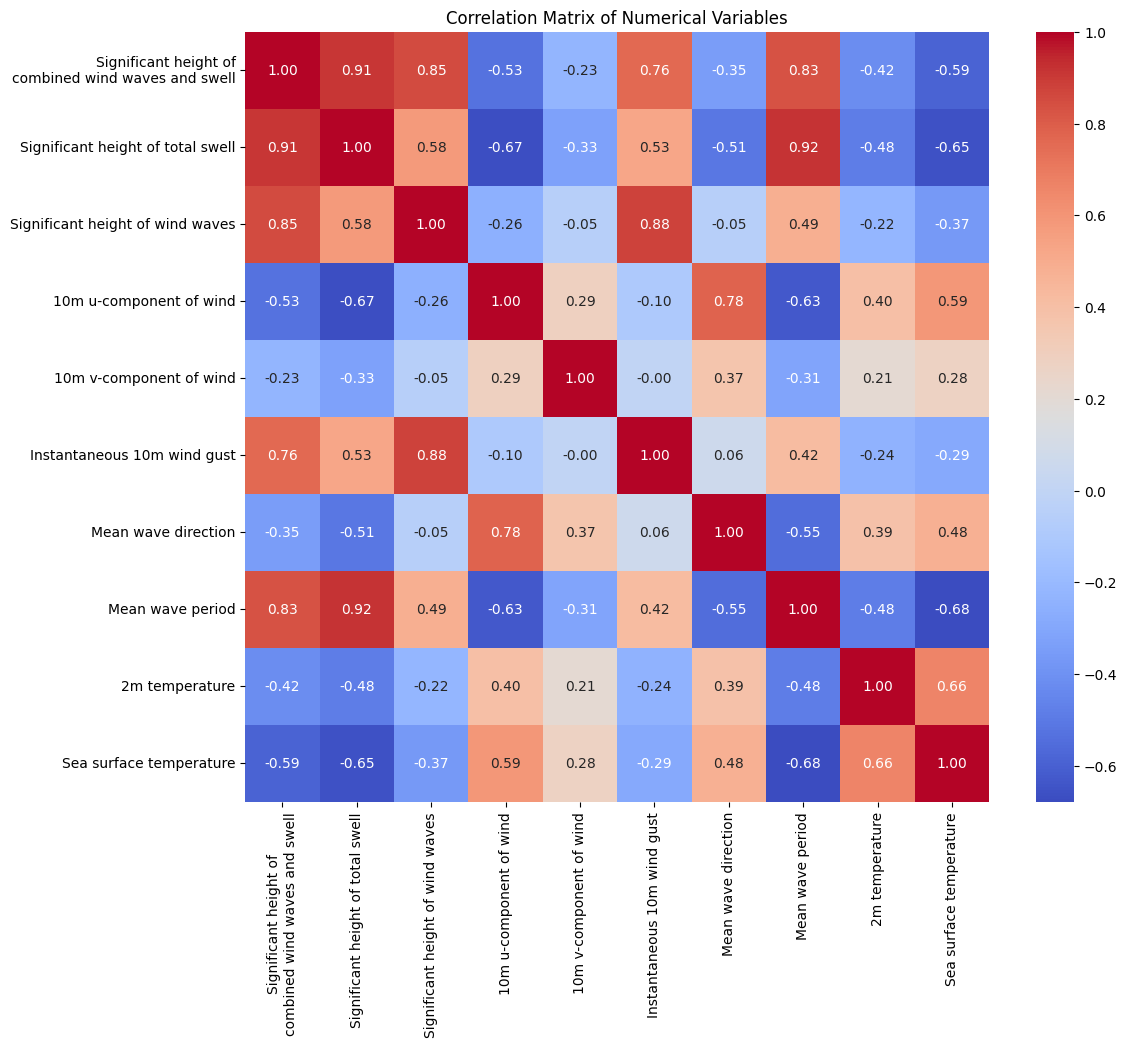

In [23]:
# Calculate the correlation matrix
correlation_matrix = HuasaiNakhonThammarat_indexed[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

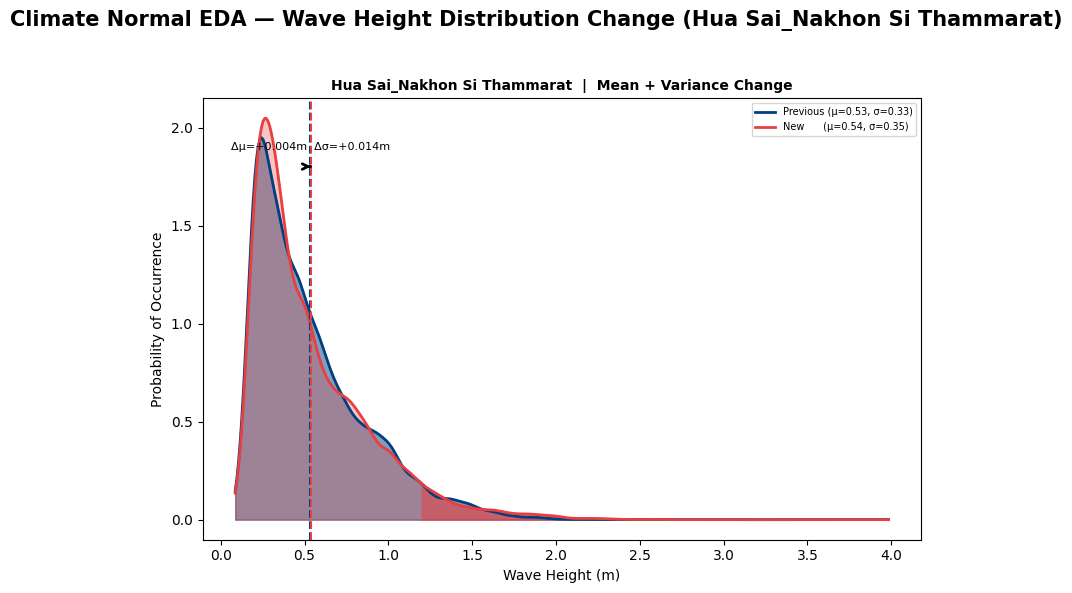

✅ saved /content/drive/MyDrive/Colab_Plots/climate_normal_eda_hua_sai_nakhon_si_thammarat.png

🔬 Statistical Tests

📍 Hua Sai_Nakhon Si Thammarat
   t-test : t=-1.728, p=0.0839 → ➖ No change
   Levene : F=9.149, p=0.0025 → ✅ Variance changed
   ➡️  Case (b): Variance only


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Use only Cha-Am data as requested by the user
df_chaam = HuasaiNakhonThammarat_indexed
name_chaam = 'Hua Sai_Nakhon Si Thammarat'

# Fix the column name to match the DataFrame (which contains a newline character)
WAVE_COL      = 'Significant height of\ncombined wind waves and swell'
PERIOD1_END   = 2021
PERIOD2_START = 2022

def split_periods(df):
    p1 = df[df.index.year <= PERIOD1_END][WAVE_COL].dropna()
    p2 = df[df.index.year >= PERIOD2_START][WAVE_COL].dropna()
    return p1, p2

colors = {'Previous': '#004080', 'New': '#E84040'}

# Adjusting subplot layout for a single plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

fig.suptitle(f"Climate Normal EDA — Wave Height Distribution Change ({name_chaam})",
             fontsize=15, fontweight='bold', y=1.01)

# Define the directory to save the plots in Google Drive
save_dir = '/content/drive/MyDrive/Colab_Plots/'
os.makedirs(save_dir, exist_ok=True)

# Process only the Cha-Am dataframe
p1, p2 = split_periods(df_chaam)

xs   = np.linspace(min(p1.min(), p2.min()), max(p1.max(), p2.max()), 400)
y1   = stats.gaussian_kde(p1)(xs)
y2   = stats.gaussian_kde(p2)(xs)

delta_mean = p2.mean() - p1.mean()
delta_std  = p2.std()  - p1.std()
ymax       = max(y1.max(), y2.max())

ax.fill_between(xs, y1, alpha=0.5, color=colors['Previous'])
ax.fill_between(xs, y2, alpha=0.3, color=colors['New'])
ax.plot(xs, y1, color=colors['Previous'], lw=2,
        label=f'Previous (μ={p1.mean():.2f}, σ={p1.std():.2f})')
ax.plot(xs, y2, color=colors['New'],      lw=2,
        label=f'New      (μ={p2.mean():.2f}, σ={p2.std():.2f})')
ax.axvline(p1.mean(), color=colors['Previous'], lw=1.5, linestyle='--')
ax.axvline(p2.mean(), color=colors['New'],      lw=1.5, linestyle='--')

# Arrow and annotation
arrow_y = ymax * 0.88
ax.annotate('',
    xy=(p2.mean(), arrow_y), xytext=(p1.mean(), arrow_y),
    arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text((p1.mean()+p2.mean())/2, arrow_y + ymax*0.04,
        f'Δμ={delta_mean:+.3f}m  Δσ={delta_std:+.3f}m',
        ha='center', fontsize=8)

tail_thresh = p1.mean() + 2 * p1.std()
ax.fill_between(xs, y2, where=(xs >= tail_thresh),
                alpha=0.5, color=colors['New'])
ax.set_title(f"{name_chaam}  |  Mean + Variance Change", fontsize=10, fontweight='bold')
ax.set_xlabel("Wave Height (m)")
ax.set_ylabel("Probability of Occurrence")
ax.legend(fontsize=7, loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plot_filename = os.path.join(save_dir, f'climate_normal_eda_{name_chaam.lower().replace(" ", "_")}.png')
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ saved {plot_filename}")

# Statistical Tests
print("\n🔬 Statistical Tests")
print("="*60)

p1, p2 = split_periods(df_chaam)
if len(p1) == 0 or len(p2) == 0:
    print(f"\n📍 {name_chaam} ⚠️ Not enough data")
else:
    t_stat, t_p = stats.ttest_ind(p1, p2)
    l_stat, l_p = stats.levene(p1, p2)
    print(f"\n📍 {name_chaam}")
    print(f"   t-test : t={t_stat:.3f}, p={t_p:.4f} → {'✅ Mean changed' if t_p<0.05 else '➖ No change'}")
    print(f"   Levene : F={l_stat:.3f}, p={l_p:.4f} → {'✅ Variance changed' if l_p<0.05 else '➖ No change'}")
    if   t_p<0.05 and l_p<0.05: print("   ➡️  Case (c): Mean AND Variance changed")
    elif t_p<0.05:               print("   ➡️  Case (a): Mean only")
    elif l_p<0.05:               print("   ➡️  Case (b): Variance only")
    else:                        print("   ➡️  No significant climate shift")

In [28]:
output_path = "/content/drive/MyDrive/eda_Hua_Sai_4.csv"
HuasaiNakhonThammarat_indexed.to_csv(output_path)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/drive/MyDrive/eda_Hua_Sai_4.csv


# Time Series Split

ข้อมูล CV  : 2018-01-01 → 2025-12-31 (70128 ชั่วโมง)
ข้อมูล Test: 2026-01-01 → 2026-02-28 (1416 ชั่วโมง)
--------------------------------------------------
--- Fold 1 ---
  Train: 2018-01-01 → 2019-05-02  (11,688 rows)
  Val  : 2019-05-03 → 2020-08-31  (11,688 rows)
--- Fold 2 ---
  Train: 2018-01-01 → 2020-08-31  (23,376 rows)
  Val  : 2020-09-01 → 2021-12-31  (11,688 rows)
--- Fold 3 ---
  Train: 2018-01-01 → 2021-12-31  (35,064 rows)
  Val  : 2022-01-01 → 2023-05-02  (11,688 rows)
--- Fold 4 ---
  Train: 2018-01-01 → 2023-05-02  (46,752 rows)
  Val  : 2023-05-03 → 2024-08-31  (11,688 rows)
--- Fold 5 ---
  Train: 2018-01-01 → 2024-08-31  (58,440 rows)
  Val  : 2024-09-01 → 2025-12-31  (11,688 rows)


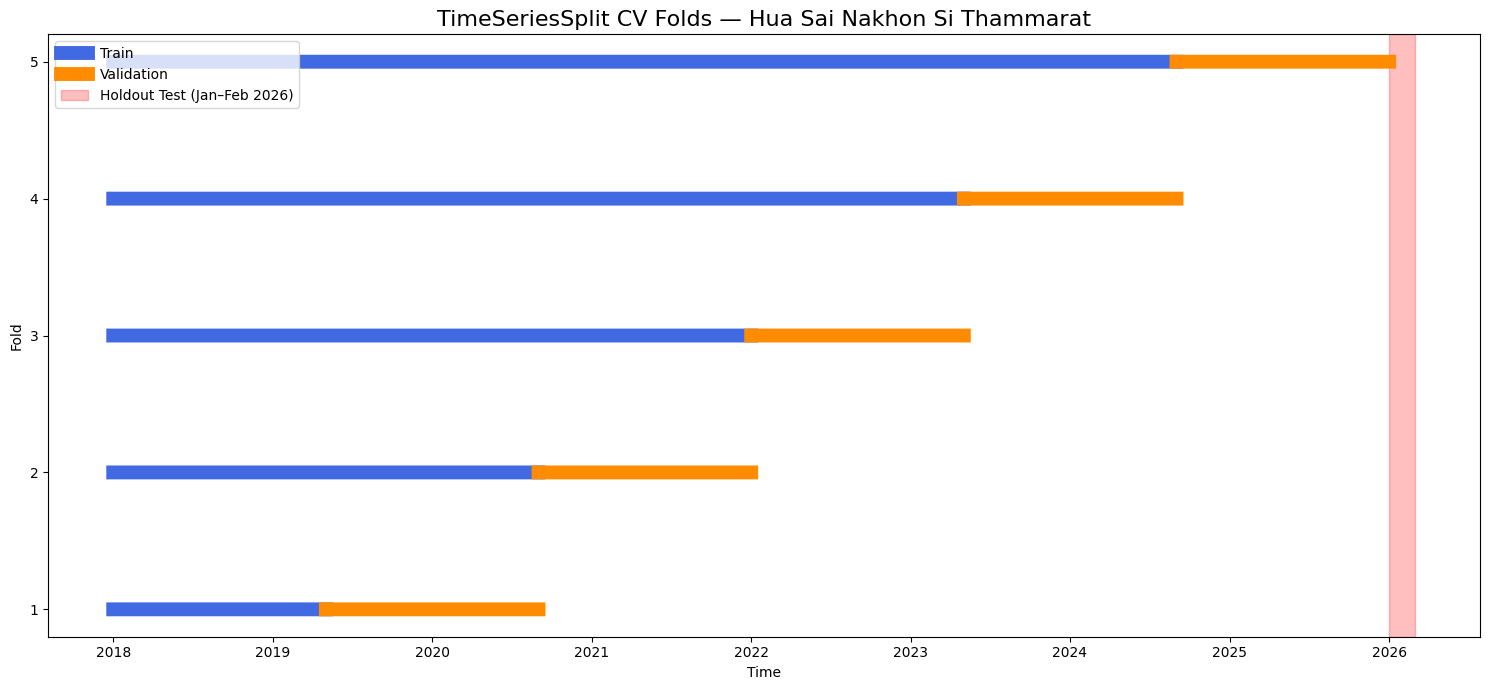

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# 1. แยก holdout test set ออกก่อนเลย
data_cv   = HuasaiNakhonThammarat_indexed.loc[:'2025-12-31'].copy()   # ใช้สำหรับ CV ทั้งหมด
data_test = HuasaiNakhonThammarat_indexed.loc['2026-01-01':'2026-02-28'].copy()  # ห้ามแตะจนกว่าจะพยากรณ์จริง

print(f"ข้อมูล CV  : {data_cv.index.min().date()} → {data_cv.index.max().date()} ({data_cv.shape[0]} ชั่วโมง)")
print(f"ข้อมูล Test: {data_test.index.min().date()} → {data_test.index.max().date()} ({data_test.shape[0]} ชั่วโมง)")
print("-" * 50)

# 2. กำหนด X, y จากข้อมูล CV เท่านั้น
TARGET = 'Significant height of\ncombined wind waves and swell'
y = data_cv[TARGET]
X = data_cv.drop(columns=[TARGET])

# 3. TimeSeriesSplit 5 folds บน data_cv
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
split_indices = {}

for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    split_indices[f'fold_{fold_num+1}_train'] = train_idx
    split_indices[f'fold_{fold_num+1}_val']   = val_idx   # ✅ เปลี่ยนชื่อเป็น val ให้ชัดเจน

    print(f"--- Fold {fold_num+1} ---")
    print(f"  Train: {X_train.index.min().date()} → {X_train.index.max().date()}  ({X_train.shape[0]:,} rows)")
    print(f"  Val  : {X_val.index.min().date()} → {X_val.index.max().date()}  ({X_val.shape[0]:,} rows)")

# 4. Visualization
fig, ax = plt.subplots(figsize=(15, 7))

for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    ax.plot(data_cv.index[train_idx], [fold_num]*len(train_idx),
            color='royalblue', lw=10, label='Train' if fold_num == 1 else "")
    ax.plot(data_cv.index[val_idx], [fold_num]*len(val_idx),
            color='darkorange', lw=10, label='Validation' if fold_num == 1 else "")

# แสดง holdout test set ด้วย
ax.axvspan(data_test.index.min(), data_test.index.max(),
           alpha=0.25, color='red', label='Holdout Test (Jan–Feb 2026)')

ax.set_title('TimeSeriesSplit CV Folds — Hua Sai Nakhon Si Thammarat', fontsize=16) # Changed title
ax.set_xlabel('Time')
ax.set_ylabel('Fold')
ax.set_yticks(range(1, N_SPLITS + 1))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
import pickle
import os

# กำหนด path ใน Google Drive
save_dir = '/content/drive/MyDrive/wave_prediction/data_split_huasai'
os.makedirs(save_dir, exist_ok=True)

# รวบรวมทุกอย่างที่ต้องการบันทึก
data_to_save = {
    # ข้อมูล CV (2018-2025)
    'X': X,
    'y': y,

    # ข้อมูล Holdout Test (Jan-Feb 2026)
    'X_test': data_test.drop(columns=[TARGET]),
    'y_test': data_test[TARGET],

    # split indices ของแต่ละ fold
    'split_indices': split_indices,

    # config
    'n_splits': N_SPLITS,
    'target_column': TARGET,
    'tscv': tscv,
}

# บันทึกเป็น pickle
save_path = os.path.join(save_dir, 'data_split_patong_huasai.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"บันทึกสำเร็จ: {save_path}")
print(f"ขนาดไฟล์: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")
print("\nสิ่งที่บันทึก:")
print(f"  X shape       : {X.shape}")
print(f"  y shape       : {y.shape}")
print(f"  X_test shape  : {data_test.drop(columns=[TARGET]).shape}")
print(f"  y_test shape  : {data_test[TARGET].shape}")
print(f"  N_SPLITS      : {N_SPLITS}")
print(f"  split_indices : {list(split_indices.keys())}")

บันทึกสำเร็จ: /content/drive/MyDrive/wave_prediction/data_split_huasai/data_split_patong_huasai.pkl
ขนาดไฟล์: 8.61 MB

สิ่งที่บันทึก:
  X shape       : (70128, 10)
  y shape       : (70128,)
  X_test shape  : (1416, 10)
  y_test shape  : (1416,)
  N_SPLITS      : 5
  split_indices : ['fold_1_train', 'fold_1_val', 'fold_2_train', 'fold_2_val', 'fold_3_train', 'fold_3_val', 'fold_4_train', 'fold_4_val', 'fold_5_train', 'fold_5_val']
